# Perceptual Straightening for Temporal Consistency in Video Generation
### Implementing PSG & MPES from *"Improving Temporal Consistency at Inference-time in Perceptual Video Restoration by Zero-shot Image-based Diffusion Models"* (Rahimi & Tekalp, 2025)

---
**Goal:** Reproduce and extend the paper's two inference-time strategies — Perceptual Straightening Guidance (PSG) and Multi-Path Ensemble Sampling (MPES) — for improving temporal coherence in diffusion-based video generation, evaluated on an RTX 4060 8 GB GPU.


# Enhanced Perceptual Straightening: AnimateDiff + Trajectory Smoothing
## Production-Grade Implementation with Multi-Decoder Comparison & Kernel Regression
### RTX 4060-Optimized with Comprehensive Analysis Suite

**Core Innovation**: Apply Retinal Latent Constraint (RLC) hypothesis to AnimateDiff temporal generation using:
- Multiple VAE decoder variants for trajectory diversity analysis
- Adaptive PSG scheduling during denoising  
- Kernel regression models (2-5 parameters) for trajectory smoothing in latent space
- Multi-scale temporal consistency measurement
- Ensemble & cross-scale fusion strategies

In [16]:
import os, json, warnings, time, glob, scipy
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import imageio
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from scipy.interpolate import UnivariateSpline
from scipy.spatial.distance import euclidean
from diffusers import MotionAdapter, AnimateDiffPipeline, DDIMScheduler
import math

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  |  {props.total_memory/1e9:.1f} GB VRAM")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  |  8.6 GB VRAM


In [ ]:
CONFIG = {
    # Model & Memory
    "model_id": "guoyww/animatediff-motion-adapter-v1-5-2",
    "base_model": "emilianJR/epiCRealism",
    "dtype": torch.float16,
    "enable_cpu_offload": True,
    "enable_vae_slicing": True,
    "enable_vae_tiling": True,
    "enable_attention_slicing": True,
    
    # Video Generation
    "prompt": "drone camera panning right, a man running on the street, blue jacket, white shorts, full screen, zoom out, city, modern, 4k",
    "neg_prompt": "static, blurry, jittery, distorted, low quality",
    "n_frames": 32,
    "height": 256,
    "width": 256,
    "n_steps": 15,
    "guidance_scale": 7.5,
    "base_seed": 42,
    
    # Perceptual Model (RetinalDN + GaborV1)
    "percept_n_scales": 3,
    "percept_n_orient": 4,
    
    # Baseline
    "run_baseline": True,
    
    # PSG Configurations
    "run_psg": True,
    "psg_lambda": 0.3,
    "psg_n_refine": 3,
    "psg_start_step": 5,
    "psg_adaptive_schedule": True,  # Increase λ as t decreases
    
    # Multi-Decoder Comparison
    "run_multi_decoder": True,
    "decoders_to_test": ["default", "tiled", "sliced"],
    
    # Trajectory Smoothing with Regression
    "run_trajectory_smoothing": True,
    "smoothing_models": [
        {"name": "linear_2param", "n_params": 2},
        {"name": "poly_3param", "n_params": 3},
        {"name": "poly_4param", "n_params": 4},
        {"name": "spline_5param", "n_params": 5},
    ],
    
    # Advanced Experiments
    "run_multi_scale_analysis": True,
    "run_ensemble_fusion": True,
    "run_adaptive_scheduling": True,
    
    # Paths
    "results_dir": "experiment-results-old",
    "fps": 4,
}

# Create output directory structure
results = Path(CONFIG["results_dir"])
for sub in ["baseline", "psg", "decoders", "trajectories", "smoothing", 
            "multi_scale", "ensemble", "plots", "metadata"]:
    (results / sub).mkdir(parents=True, exist_ok=True)

print("✓ Configuration loaded. Results root:", results.resolve())

✓ Configuration loaded. Results root: C:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\experiment-results


## Section 1: Perceptual Model & Trajectory Metrics

In [18]:
class RetinalDN(nn.Module):
    """Stage 1: Retina + LGN processing (DoG + gain control)"""
    def __init__(self, alpha=0.1, beta=0.1):
        super().__init__()
        self.alpha, self.beta = alpha, beta
        
        c = self._gauss2d(7, 1.0)
        s = self._gauss2d(7, 3.0)
        dog = (c - 0.5 * s) / (c - 0.5 * s).abs().sum()
        self.register_buffer("dog_k", dog.view(1,1,7,7))
        
        lum = self._gauss2d(9, 3.0) / self._gauss2d(9, 3.0).sum()
        self.register_buffer("lum_k", lum.view(1,1,9,9))
        
        con = self._gauss2d(5, 1.5) / self._gauss2d(5, 1.5).sum()
        self.register_buffer("con_k", con.view(1,1,5,5))

    @staticmethod
    def _gauss2d(k, σ):
        ax = torch.arange(k).float() - k // 2
        g = torch.exp(-ax**2 / (2*σ**2))
        g = g / g.sum()
        return torch.outer(g, g)

    def forward(self, x):
        B, C, H, W = x.shape
        gray = x.mean(1, keepdim=True)
        y = F.conv2d(gray.reshape(B*1, 1, H, W), self.dog_k, padding=3).reshape(B, 1, H, W)
        l = F.conv2d(gray.abs().reshape(B, 1, H, W), self.lum_k, padding=4).clamp(min=0)
        y = y / (1.0 + self.alpha * l)
        c = (F.conv2d(y.reshape(B, 1, H, W), self.con_k, padding=2).pow(2) + 1e-8).sqrt()
        y = y / (1.0 + self.beta * c)
        return F.softplus(y).expand(B, 3, H, W)


class GaborV1(nn.Module):
    """Stage 2: V1-like Gabor filter bank for perceptual features"""
    def __init__(self, n_scales=3, n_orient=4, pool_size=16):
        super().__init__()
        self.pool_size = pool_size
        filters, ksizes = [], []
        
        for s in range(n_scales):
            σ = 2.0 ** s
            lam = σ * 2.0
            k = int(4 * σ + 1) | 1
            for o in range(n_orient):
                θ = o * np.pi / n_orient
                filters.append(self._gabor(k, σ, θ, lam))
                ksizes.append(k)
        
        K = max(ksizes)
        padded = []
        for f, k in zip(filters, ksizes):
            pad = (K - k) // 2
            padded.append(F.pad(f.view(1,1,k,k), [pad]*4))
        self.register_buffer("weight", torch.cat(padded, 0))
        self.pad = K // 2

    @staticmethod
    def _gabor(k, σ, θ, lam):
        y, x = torch.meshgrid(torch.arange(k).float() - k//2, torch.arange(k).float() - k//2, indexing="ij")
        Xp = x*np.cos(θ) + y*np.sin(θ)
        Yp = -x*np.sin(θ) + y*np.cos(θ)
        env = torch.exp(-(Xp**2 + Yp**2) / (2*σ**2))
        car = torch.cos(2*np.pi * Xp / lam)
        g = env * car
        return g / (g.abs().sum() + 1e-8)

    def forward(self, x):
        gray = x.mean(1, keepdim=True)
        resp = F.conv2d(gray, self.weight, padding=self.pad)
        energy = resp ** 2
        pooled = F.adaptive_avg_pool2d(energy, self.pool_size)
        return pooled.flatten(1)


class PerceptualModel(nn.Module):
    """Two-stage: RetinalDN → GaborV1"""
    def __init__(self, n_scales=3, n_orient=4):
        super().__init__()
        self.retina = RetinalDN()
        self.v1 = GaborV1(n_scales, n_orient)

    def forward(self, x):
        return self.v1(self.retina(x))


def compute_curvature(features):
    """Mean angle between consecutive displacements in feature space"""
    if features.shape[0] < 3:
        return torch.tensor(0.0, device=features.device)
    V = features[1:] - features[:-1]
    d = (V[:-1] * V[1:]).sum(1)
    n1 = V[:-1].norm(dim=1).clamp(min=1e-8)
    n2 = V[1:].norm(dim=1).clamp(min=1e-8)
    cos = (d / (n1 * n2)).clamp(-1+1e-6, 1-1e-6)
    return torch.acos(cos).mean()


def straightness_score(features):
    """Curvature→straightness (0-100)"""
    c = compute_curvature(features).item()
    return (1.0 - c / np.pi) * 100.0 if c > 0 else 50.0


def compute_temporal_consistency(frames, frame_diff_metric="mse"):
    """Frame-to-frame consistency metric"""
    if frame_diff_metric == "mse":
        diffs = [(frames[i] - frames[i+1]).pow(2).mean().item() for i in range(len(frames)-1)]
    else:  # perceptual (LPIPS would require external model)
        diffs = [euclidean(frames[i].flatten().cpu().numpy(), frames[i+1].flatten().cpu().numpy()) 
                 for i in range(len(frames)-1)]
    return float(np.mean(diffs)) if diffs else 0.0


perc_model = PerceptualModel(CONFIG["percept_n_scales"], CONFIG["percept_n_orient"]).to(DEVICE).eval()
print("✓ Perceptual model initialized")

✓ Perceptual model initialized


## Section 2: Model Loading & Multi-Decoder Setup

In [19]:
torch.cuda.empty_cache()

print("Loading AnimateDiff Pipeline...")
adapter = MotionAdapter.from_pretrained(CONFIG["model_id"], torch_dtype=CONFIG["dtype"])
pipe = AnimateDiffPipeline.from_pretrained(
    CONFIG["base_model"],
    motion_adapter=adapter,
    torch_dtype=CONFIG["dtype"],
).to(DEVICE)

if CONFIG["enable_cpu_offload"]:
    pipe.enable_sequential_cpu_offload()
if CONFIG["enable_vae_slicing"]:
    pipe.enable_vae_slicing()
if CONFIG["enable_vae_tiling"]:
    pipe.enable_vae_tiling()
if CONFIG["enable_attention_slicing"]:
    pipe.enable_attention_slicing()

pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config,
    beta_schedule="linear",
    clip_sample=False,
    timestep_spacing="linspace",
    steps_offset=1,
)
print("✓ AnimateDiff Pipeline loaded")


class MultiDecoderManager:
    """Manages different VAE decoder implementations for trajectory analysis"""
    def __init__(self, pipe, device):
        self.pipe = pipe
        self.device = device
        self.vae = pipe.vae
        self.scale_factor = self.vae.config.scaling_factor
        self.decoders = {}
        self._init_decoders()

    def _init_decoders(self):
        """Initialize different decoder variants"""
        self.decoders["default"] = self._decode_default
        self.decoders["tiled"] = self._decode_tiled
        self.decoders["sliced"] = self._decode_sliced

    def _decode_default(self, latents):
        """Standard VAE decode"""
        with torch.no_grad():
            frames = self.vae.decode(latents / self.scale_factor).sample
        return frames.float().clamp(-1, 1)

    def _decode_tiled(self, latents):
        """Tiled decode for memory efficiency"""
        with torch.no_grad():
            # Process frames in groups
            frames_list = []
            for i in range(latents.shape[1]):
                lat_i = latents[:, i:i+1]
                frame_i = self.vae.decode(lat_i / self.scale_factor).sample
                frames_list.append(frame_i)
            frames = torch.cat(frames_list, dim=1)
        return frames.float().clamp(-1, 1)

    def _decode_sliced(self, latents):
        """Sliced decode with stride"""
        with torch.no_grad():
            # Batch decode with interior padding
            orig_dtype = latents.dtype
            latents_fp32 = latents.float()
            frames = self.vae.decode(latents_fp32 / self.scale_factor).sample
            frames = frames.to(orig_dtype)
        return frames.clamp(-1, 1)

    def decode(self, latents, decoder_name="default"):
        """Decode using specified decoder"""
        if decoder_name not in self.decoders:
            print(f"Unknown decoder {decoder_name}, using default")
            decoder_name = "default"
        return self.decoders[decoder_name](latents)


decoder_manager = MultiDecoderManager(pipe, DEVICE)
print("✓ Multi-decoder manager initialized")

Loading AnimateDiff Pipeline...


The config attributes {'motion_activation_fn': 'geglu', 'motion_attention_bias': False, 'motion_cross_attention_dim': None} were passed to MotionAdapter, but are not expected and will be ignored. Please verify your config.json configuration file.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1051.31it/s]1.99s/it]
CLIPTextModel LOAD REPORT from: C:\Users\Suchit\.cache\huggingface\hub\models--emilianJR--epiCRealism\snapshots\6522cf856b8c8e14638a0aaa7bd89b1b098aed17\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:07<00:00,  1.24s/it]


✓ AnimateDiff Pipeline loaded
✓ Multi-decoder manager initialized


## Section 3: Baseline Generation Pipeline

In [20]:
def to_pil(frames):
    """Convert [-1,1] tensor to PIL images"""
    imgs = []
    for f in frames.cpu():
        arr = ((f.numpy().transpose(1,2,0)+1)/2*255).clip(0,255).astype(np.uint8)
        imgs.append(Image.fromarray(arr))
    return imgs


def save_video_gif(frames, path, fps=4):
    """Save video as GIF"""
    imageio.mimsave(str(path), [np.array(p) for p in to_pil(frames)],
                    fps=fps, codec="libx264", quality=8)


def save_frames(frames, folder):
    """Save individual frames"""
    Path(folder).mkdir(parents=True, exist_ok=True)
    for i, img in enumerate(to_pil(frames)):
        img.save(Path(folder) / f"frame_{i:02d}.png")


def compute_metrics(frames, perc_model, device=DEVICE):
    """Compute temporal quality metrics"""
    frames_01 = ((frames + 1) / 2).to(device)
    with torch.no_grad():
        feats = perc_model(frames_01)
    curv = compute_curvature(feats).item()
    straight = straightness_score(feats)
    t_consistency = compute_temporal_consistency(frames, "mse")
    
    return {
        "curvature": curv,
        "straightness": straight,
        "temporal_consistency": t_consistency,
        "features": feats.cpu().numpy(),
    }


def print_metrics(name, m):
    print(f"{name:<25}  curv={m['curvature']:.4f}  "
          f"straight={m['straightness']:.1f}%  t-cons={m['temporal_consistency']:.5f}")


@torch.no_grad()
def generate_baseline(n_frames=None, n_steps=None, seed=None):
    """Generate video without any constraints"""
    n_frames = n_frames or CONFIG["n_frames"]
    n_steps = n_steps or CONFIG["n_steps"]
    seed = seed or CONFIG["base_seed"]
    
    print(f"Generating baseline (frames={n_frames}, steps={n_steps})...")
    t0 = time.time()
    
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    output = pipe(
        prompt=CONFIG["prompt"],
        negative_prompt=CONFIG["neg_prompt"],
        num_frames=n_frames,
        height=CONFIG["height"],
        width=CONFIG["width"],
        num_inference_steps=n_steps,
        guidance_scale=CONFIG["guidance_scale"],
        generator=generator,
        output_type="pt",
    )
    frames = output.frames.squeeze(0)  # [T, C, H, W]
    metrics = compute_metrics(frames, perc_model)
    
    # Save
    save_video_gif(frames, results/"baseline"/"video.gif", CONFIG["fps"])
    save_frames(frames, results/"baseline"/"frames")
    
    elapsed = time.time() - t0
    print(f"Done in {elapsed:.1f}s")
    print_metrics("Baseline", metrics)
    
    torch.cuda.empty_cache()
    return frames, metrics


if CONFIG["run_baseline"]:
    baseline_frames, baseline_m = generate_baseline()
else:
    baseline_frames = None
    baseline_m = None

Generating baseline (frames=32, steps=15)...


100%|██████████| 15/15 [00:44<00:00,  2.95s/it]


Done in 51.0s
Baseline                   curv=2.0306  straight=35.4%  t-cons=0.00671


## Section 4: PSG with Adaptive Scheduling

In [21]:
class PSGCallback:
    """Perceptual Straightening Guidance applied during denoising"""
    def __init__(self, perc_model, lambda_ps, n_refine, start_step, n_steps, device=DEVICE):
        self.perc_model = perc_model
        self.lambda_ps = lambda_ps
        self.n_refine = n_refine
        self.start_step = start_step
        self.n_steps = n_steps
        self.device = device
        self.latent_trajectory = []
        # Get dtype from model parameters or buffers (model only has buffers, no parameters)
        try:
            self.perc_dtype = next(perc_model.parameters()).dtype
        except StopIteration:
            self.perc_dtype = next(perc_model.buffers()).dtype
        # Get VAE dtype to avoid mismatches
        try:
            self.vae_dtype = next(decoder_manager.vae.parameters()).dtype
        except StopIteration:
            self.vae_dtype = next(decoder_manager.vae.buffers()).dtype

    def _get_adaptive_lambda(self, step_idx):
        """Adaptive scheduling: increase λ as denoising progresses"""
        if not CONFIG["psg_adaptive_schedule"]:
            return self.lambda_ps
        progress = step_idx / self.n_steps
        # Cosine schedule: ramp up near end (low progress)
        adaptive = self.lambda_ps * (0.5 * (1 + np.cos(np.pi * progress)))
        return adaptive

    def _decode_temporal(self, latents):
        frames_list = []

        for i in range(latents.shape[1]):
            lat_i = latents[:, i, :4]  # [B, 4, H, W]

            frame_i = decoder_manager.vae.decode(
                lat_i / decoder_manager.scale_factor
            ).sample

            frames_list.append(frame_i.unsqueeze(1))

        decoded = torch.cat(frames_list, dim=1)
        return decoded.float().clamp(-1, 1)

    def __call__(self, pipe, step_index, timestep, callback_kwargs):
        latents = callback_kwargs["latents"]  # [B, F, 4, H, W]
        latent_orig_dtype = latents.dtype
        
        if step_index >= self.start_step:
            lambda_adaptive = self._get_adaptive_lambda(step_index)
            
            # Decode to pixel space for perceptual analysis
            # Cast to VAE dtype and rescale
            latents_scaled = latents.to(self.vae_dtype) * 0.18215
            decoded = self._decode_temporal(latents_scaled)
            decoded_01 = ((decoded + 1) / 2).clamp(0, 1)
            
            # Compute curvature in perceptual space
            # Cast to perceptual model dtype
            B, T, C, H, W = decoded_01.shape
            decoded_reshaped = decoded_01.view(B * T, C, H, W)

            feats = self.perc_model(decoded_reshaped.to(self.perc_dtype))
            feats = feats.view(B, T, -1)
            curv = torch.stack([
                compute_curvature(feats[b])
                for b in range(B)
            ]).mean()
            
            if curv > 1e-6:
                with torch.enable_grad():   # 🔥 THIS IS KEY

                    # Refine latents via gradient descent on curvature
                    # Keep in float32 for numerical stability
                    latents_refined = latents.float().clone().requires_grad_(True)
                    opt = torch.optim.Adam([latents_refined], lr=lambda_adaptive / 100.0)
                    
                    for _ in range(min(self.n_refine, 2)):  # Light refinement for speed
                        opt.zero_grad()
                        # Decode refined latents
                        latents_scaled = latents_refined.to(self.vae_dtype) * 0.18215
                        dec = self._decode_temporal(latents_scaled)
                        dec_01 = ((dec + 1) / 2).clamp(0, 1)
                        B, T, C, H, W = dec_01.shape
                        dec_reshaped = dec_01.view(B * T, C, H, W)

                        feats_ref = self.perc_model(dec_reshaped.to(self.perc_dtype))
                                            
                        feats_ref = feats_ref.view(B, T, -1)
                        curv = torch.stack([
                            compute_curvature(feats_ref[b])
                            for b in range(B)
                        ]).mean()
                        loss = F.relu(curv)
                        loss.backward()
                        opt.step()
                    
                    # Convert back to original latent dtype before returning
                    latents = latents_refined.detach().to(latent_orig_dtype)
            else:
                # No refinement, keep original dtype
                latents = latents.to(latent_orig_dtype)
        
        self.latent_trajectory.append(latents.detach().cpu().float().numpy())
        callback_kwargs["latents"] = latents
        return callback_kwargs


@torch.no_grad()
def generate_with_psg(lambda_ps=None, n_refine=None, start_step=None, n_frames=None, n_steps=None, seed=None):
    """Generate with Perceptual Straightening Guidance"""
    lambda_ps = lambda_ps or CONFIG["psg_lambda"]
    n_refine = n_refine or CONFIG["psg_n_refine"]
    start_step = start_step or CONFIG["psg_start_step"]
    n_frames = n_frames or CONFIG["n_frames"]
    n_steps = n_steps or CONFIG["n_steps"]
    seed = seed or CONFIG["base_seed"]
    
    print(f"Generating with PSG (λ={lambda_ps}, refine_steps={n_refine}, start={start_step})...")
    t0 = time.time()
    
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    psg_callback = PSGCallback(perc_model, lambda_ps, n_refine, start_step, n_steps, DEVICE)
    
    # Run pipeline
    output = pipe(
        prompt=CONFIG["prompt"],
        negative_prompt=CONFIG["neg_prompt"],
        num_frames=n_frames,
        height=CONFIG["height"],
        width=CONFIG["width"],
        num_inference_steps=n_steps,
        guidance_scale=CONFIG["guidance_scale"],
        generator=generator,
        output_type="pt",
        callback_on_step_end=psg_callback,
        callback_on_step_end_tensor_inputs=["latents"],
    )
    
    frames = output.frames.squeeze(0)
    metrics = compute_metrics(frames, perc_model)
    
    save_video_gif(frames, results/"psg"/f"video_lambda{lambda_ps:.2f}.gif", CONFIG["fps"])
    save_frames(frames, results/"psg"/f"frames_lambda{lambda_ps:.2f}")
    
    elapsed = time.time() - t0
    print(f"Done in {elapsed:.1f}s")
    print_metrics(f"PSG (λ={lambda_ps})", metrics)
    
    torch.cuda.empty_cache()
    return frames, metrics, psg_callback.latent_trajectory


if CONFIG["run_psg"]:
    psg_frames, psg_m, psg_latent_traj = generate_with_psg()

Generating with PSG (λ=0.3, refine_steps=3, start=5)...


100%|██████████| 15/15 [01:11<00:00,  4.75s/it]


Done in 77.8s
PSG (λ=0.3)                curv=2.0319  straight=35.3%  t-cons=0.00674


## Section 5: Multi-Decoder Comparison

In [22]:
if CONFIG["run_multi_decoder"]:
    decoder_results = {}
    print("\n=== Multi-Decoder Comparison ===")
    
    for decoder_name in CONFIG["decoders_to_test"]:
        print(f"\nTesting decoder: {decoder_name}")
        
        # Generate baseline with this decoder
        generator = torch.Generator(device=DEVICE).manual_seed(CONFIG["base_seed"])
        output = pipe(
            prompt=CONFIG["prompt"],
            negative_prompt=CONFIG["neg_prompt"],
            num_frames=CONFIG["n_frames"],
            height=CONFIG["height"],
            width=CONFIG["width"],
            num_inference_steps=12,  # Reduced for speed
            guidance_scale=CONFIG["guidance_scale"],
            generator=generator,
            output_type="pt",
        )
        frames = output.frames.squeeze(0)
        metrics = compute_metrics(frames, perc_model)
        decoder_results[decoder_name] = metrics
        
        save_video_gif(frames, results/"decoders"/f"video_{decoder_name}.gif", CONFIG["fps"])
        print_metrics(f"Decoder: {decoder_name}", metrics)
        torch.cuda.empty_cache()
else:
    decoder_results = {}


=== Multi-Decoder Comparison ===

Testing decoder: default


100%|██████████| 12/12 [00:33<00:00,  2.83s/it]


Decoder: default           curv=2.0600  straight=34.4%  t-cons=0.00613

Testing decoder: tiled


100%|██████████| 12/12 [00:35<00:00,  2.92s/it]


Decoder: tiled             curv=2.0600  straight=34.4%  t-cons=0.00613

Testing decoder: sliced


100%|██████████| 12/12 [00:35<00:00,  2.95s/it]


Decoder: sliced            curv=2.0600  straight=34.4%  t-cons=0.00613


## Section 6: Trajectory Smoothing via Kernel Regression

In [23]:
class FeatureSpaceSmoother:
    """Smooth trajectories in perceptual feature space and reconstruct frames"""

    @staticmethod
    def extract_features(frames):
        frames_01 = ((frames + 1) / 2).clamp(0, 1)
        with torch.no_grad():
            feats = perc_model(frames_01)
        return feats  # [T, D]

    @staticmethod
    def smooth_features(feats, model_type):
        feats_np = feats.cpu().numpy()
        T, D = feats_np.shape
        t = np.arange(T)

        if model_type == "linear_2param":
            X = t[:, None]
            ridge = Ridge(alpha=1.0)
        elif model_type == "poly_3param":
            X = np.vstack([t**i for i in range(3)]).T
            ridge = Ridge(alpha=0.1)
        elif model_type == "poly_4param":
            X = np.vstack([t**i for i in range(4)]).T
            ridge = Ridge(alpha=0.1)
        elif model_type == "spline_5param":
            smoothed = np.zeros_like(feats_np)
            for d in range(D):
                try:
                    spl = UnivariateSpline(t, feats_np[:, d], k=3, s=T*0.01)
                    smoothed[:, d] = spl(t)
                except:
                    smoothed[:, d] = feats_np[:, d]
            return torch.from_numpy(smoothed).to(feats.device).type(feats.dtype)
        else:
            return feats

        ridge.fit(X, feats_np)
        smoothed = ridge.predict(X)
        return torch.from_numpy(smoothed).to(feats.device).type(feats.dtype)

    @staticmethod
    def reconstruct_frames(frames_init, target_feats, n_iter=50, lr=0.05):
        """
        Optimize frames so that perceptual features match target features
        """
        frames = frames_init.clone().detach().float().requires_grad_(True)
        optimizer = torch.optim.Adam([frames], lr=lr)

        for _ in range(n_iter):
            optimizer.zero_grad()

            frames_01 = ((frames + 1) / 2).clamp(0, 1)
            feats = perc_model(frames_01)

            loss = F.mse_loss(feats, target_feats)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                frames.clamp_(-1, 1)

        return frames.detach()

    @staticmethod
    def smooth(frames, model_type):
        feats = FeatureSpaceSmoother.extract_features(frames)
        feats_smooth = FeatureSpaceSmoother.smooth_features(feats, model_type)
        frames_smooth = FeatureSpaceSmoother.reconstruct_frames(frames, feats_smooth)
        return frames_smooth


def compute_trajectory_quality(frames):
    frames_01 = ((frames + 1) / 2).clamp(0, 1).to(DEVICE)
    with torch.no_grad():
        feats = perc_model(frames_01)

    curv = compute_curvature(feats).item()
    straight = straightness_score(feats)

    diffs = torch.diff(frames.float(), dim=0)
    velocity_variance = diffs.std().item()
    
    t_consistency = compute_temporal_consistency(frames, "mse")

    return {
        "curvature": curv,
        "straightness": straight,
        "velocity_variance": velocity_variance,
    }


# ─────────────────────────────────────────────────────────────

if CONFIG["run_trajectory_smoothing"]:
    smoothing_results = {}
    print("\n=== Feature-Space Trajectory Smoothing ===")

    if baseline_frames is not None:
        baseline_perf = compute_trajectory_quality(baseline_frames)

        print(f"\nBaseline trajectory quality:")
        print(f"  Curvature: {baseline_perf['curvature']:.4f}")
        print(f"  Straightness: {baseline_perf['straightness']:.1f}%")
        print(f"  Velocity Variance: {baseline_perf['velocity_variance']:.6f}")

        for model_cfg in CONFIG["smoothing_models"]:
            name = model_cfg["name"]

            print(f"\nApplying {name} smoothing (feature space)...")

            smoothed_frames = FeatureSpaceSmoother.smooth(baseline_frames, name)
            smoothed_perf = compute_trajectory_quality(smoothed_frames)

            smoothing_results[name] = {
                "performance": smoothed_perf,
                "frames": smoothed_frames,
            }

            print(f"  Curvature: {smoothed_perf['curvature']:.4f} (Δ {smoothed_perf['curvature']-baseline_perf['curvature']:+.4f})")
            print(f"  Straightness: {smoothed_perf['straightness']:.1f}% (Δ {smoothed_perf['straightness']-baseline_perf['straightness']:+.1f})")
            print(f"  Velocity Variance: {smoothed_perf['velocity_variance']:.6f} (Δ {smoothed_perf['velocity_variance']-baseline_perf['velocity_variance']:+.6f})")

            save_video_gif(smoothed_frames, results/"smoothing"/f"video_{name}.gif", CONFIG["fps"])

else:
    smoothing_results = {}


=== Feature-Space Trajectory Smoothing ===

Baseline trajectory quality:
  Curvature: 2.0306
  Straightness: 35.4%
  Velocity Variance: 0.081884

Applying linear_2param smoothing (feature space)...
  Curvature: 2.0306 (Δ -0.0000)
  Straightness: 35.4% (Δ +0.0)
  Velocity Variance: 0.081882 (Δ -0.000002)

Applying poly_3param smoothing (feature space)...
  Curvature: 2.0306 (Δ +0.0000)
  Straightness: 35.4% (Δ -0.0)
  Velocity Variance: 0.081882 (Δ -0.000002)

Applying poly_4param smoothing (feature space)...
  Curvature: 2.0306 (Δ +0.0000)
  Straightness: 35.4% (Δ -0.0)
  Velocity Variance: 0.081882 (Δ -0.000002)

Applying spline_5param smoothing (feature space)...
  Curvature: 2.0306 (Δ +0.0000)
  Straightness: 35.4% (Δ -0.0)
  Velocity Variance: 0.081882 (Δ -0.000002)


## Section 7: Advanced Experiments (Multi-Scale, Ensemble, Adaptive)

In [24]:
if CONFIG["run_multi_scale_analysis"]:
    print("\n=== Multi-Scale Temporal Analysis ===")
    
    if baseline_frames is not None:
        # Analyze different temporal scales
        scales = [1, 2, 4]  # Frame stride
        scale_results = {}
        
        for scale in scales:
            frames_downsampled = baseline_frames[::scale]  # Skip every nth frame
            perf = compute_trajectory_quality(frames_downsampled)
            scale_results[f"scale_{scale}"] = perf
            
            print(f"Scale {scale}x (frames={len(frames_downsampled)}):")
            print(f"  Straightness: {perf['straightness']:.1f}%")


if CONFIG["run_ensemble_fusion"]:
    print("\n=== Ensemble Fusion Experiment (Perceptual) ===")
    
    if baseline_frames is not None:
        seeds = [CONFIG["base_seed"], CONFIG["base_seed"]+1, CONFIG["base_seed"]+2]
        ensemble_frames_list = []

        print("Generating ensemble members...")
        for seed in seeds:
            gen = torch.Generator(device=DEVICE).manual_seed(seed)
            output = pipe(
                prompt=CONFIG["prompt"],
                negative_prompt=CONFIG["neg_prompt"],
                num_frames=CONFIG["n_frames"],
                height=CONFIG["height"],
                width=CONFIG["width"],
                num_inference_steps=12,
                guidance_scale=CONFIG["guidance_scale"],
                generator=gen,
                output_type="pt",
            )
            frames_i = output.frames.squeeze(0)  # [T,C,H,W]
            ensemble_frames_list.append(frames_i)
            torch.cuda.empty_cache()

        # Stack → [K, T, C, H, W]
        ensemble_tensor = torch.stack(ensemble_frames_list).to(DEVICE)

        # =========================================================
        # 🔹 Step 1: Compute perceptual features for each trajectory
        # =========================================================
        with torch.no_grad():
            feats_list = []
            for k in range(len(ensemble_tensor)):
                frames_01 = ((ensemble_tensor[k] + 1) / 2).clamp(0,1)
                feats = perc_model(frames_01)  # [T, D]
                feats_list.append(feats)

            feats_tensor = torch.stack(feats_list)  # [K, T, D]

        # =========================================================
        # 🔥 STRATEGY 1: PERCEPTUAL MEDOID (RECOMMENDED)
        # =========================================================
        print("\nComputing perceptual medoid trajectory...")

        K = feats_tensor.shape[0]
        dist_matrix = torch.zeros(K, K, device=DEVICE)

        for i in range(K):
            for j in range(K):
                dist = ((feats_tensor[i] - feats_tensor[j])**2).mean()
                dist_matrix[i, j] = dist

        medoid_idx = dist_matrix.sum(dim=1).argmin().item()
        ensemble_medoid = ensemble_tensor[medoid_idx]

        medoid_perf = compute_trajectory_quality(ensemble_medoid)

        print(f"Medoid trajectory selected: index {medoid_idx}")
        print(f"  Straightness: {medoid_perf['straightness']:.1f}%")

        save_video_gif(
            ensemble_medoid,
            results/"ensemble"/"video_medoid.gif",
            CONFIG["fps"]
        )

        # =========================================================
        # 🔥 STRATEGY 2: PERCEPTUAL WEIGHTED FUSION
        # =========================================================
        print("\nComputing perceptual weighted fusion...")

        # Compute mean trajectory in feature space
        feat_mean = feats_tensor.mean(dim=0, keepdim=True)  # [1,T,D]

        # Compute weights based on similarity to mean
        weights = []
        for k in range(K):
            dist = ((feats_tensor[k] - feat_mean[0])**2).mean()
            weights.append(torch.exp(-dist))

        weights = torch.stack(weights)  # [K]
        weights = weights / weights.sum()

        # Weighted combination
        ensemble_weighted = torch.sum(
            ensemble_tensor * weights.view(K,1,1,1,1),
            dim=0
        )

        weighted_perf = compute_trajectory_quality(ensemble_weighted)

        print(f"Weighted fusion:")
        print(f"  Straightness: {weighted_perf['straightness']:.1f}%")

        save_video_gif(
            ensemble_weighted,
            results/"ensemble"/"video_weighted.gif",
            CONFIG["fps"]
        )

        # =========================================================
        # 🔥 STRATEGY 3: (Optional) BEST FRAME PER TIME STEP
        # =========================================================
        print("\nComputing frame-wise perceptual selection...")

        T = ensemble_tensor.shape[1]
        best_frames = []

        for t in range(T):
            # Compute feature similarity at frame t
            feats_t = feats_tensor[:, t]  # [K, D]
            mean_t = feats_t.mean(dim=0, keepdim=True)

            dists = ((feats_t - mean_t)**2).mean(dim=1)
            best_idx = torch.argmin(dists)

            best_frames.append(ensemble_tensor[best_idx, t])

        ensemble_best_frame = torch.stack(best_frames)

        best_perf = compute_trajectory_quality(ensemble_best_frame)

        print(f"Frame-wise selection:")
        print(f"  Straightness: {best_perf['straightness']:.1f}%")

        save_video_gif(
            ensemble_best_frame,
            results/"ensemble"/"video_framewise.gif",
            CONFIG["fps"]
        )

if CONFIG["run_adaptive_scheduling"]:
    print("\n=== Adaptive PSG Scheduling ===")
    
    # Test different lambda schedules
    schedules = [
        {"name": "constant", "lambdas": [0.3]*5},
        {"name": "linear_ramp", "lambdas": np.linspace(0.1, 0.5, 5).tolist()},
        {"name": "cosine_ramp", "lambdas": [0.3 * (0.5 * (1 + np.cos(np.pi * i/4))) for i in range(5)]},
    ]
    
    print("Testing lambda schedules (visualization only)...")
    for schedule_cfg in schedules:
        name = schedule_cfg["name"]
        lambdas = schedule_cfg["lambdas"]
        print(f"  {name}: {[f'{l:.2f}' for l in lambdas]}")


=== Multi-Scale Temporal Analysis ===
Scale 1x (frames=32):
  Straightness: 35.4%
Scale 2x (frames=16):
  Straightness: 36.4%
Scale 4x (frames=8):
  Straightness: 40.0%

=== Ensemble Fusion Experiment (Perceptual) ===
Generating ensemble members...


100%|██████████| 12/12 [00:33<00:00,  2.82s/it]



Computing perceptual medoid trajectory...
Medoid trajectory selected: index 1
  Straightness: 34.7%

Computing perceptual weighted fusion...
Weighted fusion:
  Straightness: 35.3%

Computing frame-wise perceptual selection...
Frame-wise selection:
  Straightness: 37.2%

=== Adaptive PSG Scheduling ===
Testing lambda schedules (visualization only)...
  constant: ['0.30', '0.30', '0.30', '0.30', '0.30']
  linear_ramp: ['0.10', '0.20', '0.30', '0.40', '0.50']
  cosine_ramp: ['0.30', '0.26', '0.15', '0.04', '0.00']


## Section 8: Analysis & Visualization Suite

In [15]:
def plot_trajectory_pca(frames_dict, output_path):
    """Project frame trajectories to 2D via PCA and visualize"""
    all_f = []
    for frames in frames_dict.values():
        frames_01 = ((frames + 1) / 2).clamp(0, 1).to(DEVICE)
        with torch.no_grad():
            feats = perc_model(frames_01)
        all_f.append(feats.cpu().numpy())
    
    all_f = np.vstack(all_f)
    pca = PCA(n_components=2).fit(all_f)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = plt.cm.tab10(np.linspace(0, 0.7, len(frames_dict)))
    
    offset = 0
    for (name, frames), col in zip(frames_dict.items(), colors):
        frames_01 = ((frames + 1) / 2).clamp(0, 1).to(DEVICE)
        with torch.no_grad():
            feats = perc_model(frames_01)
        pca_proj = pca.transform(feats.cpu().numpy())
        
        ax.plot(pca_proj[:, 0], pca_proj[:, 1], "-o", color=col, label=name, ms=5, lw=2)
        ax.scatter(pca_proj[0, 0], pca_proj[0, 1], color=col, marker='s', s=100, zorder=5)
        ax.scatter(pca_proj[-1, 0], pca_proj[-1, 1], color=col, marker='^', s=100, zorder=5)
    
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title("Perceptual Trajectory Space (PCA)\n■=start, ▲=end")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {output_path}")


def plot_metrics_comparison(metrics_dict, output_dir):
    """Create comparison plots for all metrics"""
    metrics_dict = {k: v for k, v in metrics_dict.items() if v is not None}
    if not metrics_dict:
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    names = list(metrics_dict.keys())
    
    curv_vals = [metrics_dict[n].get("curvature", 0) for n in names]
    straight_vals = [metrics_dict[n].get("straightness", 0) for n in names]
    cons_vals = [metrics_dict[n].get("temporal_consistency", 0) for n in names]
    
    axes[0].bar(names, curv_vals, color="skyblue", edgecolor="black")
    axes[0].set_ylabel("Curvature ↓")
    axes[0].set_title("Trajectory Curvature")
    axes[0].tick_params(axis='x', rotation=45)
    
    axes[1].bar(names, straight_vals, color="lightgreen", edgecolor="black")
    axes[1].set_ylabel("Straightness % ↑")
    axes[1].set_title("Perceptual Straightness")
    axes[1].tick_params(axis='x', rotation=45)
    
    axes[2].bar(names, cons_vals, color="salmon", edgecolor="black")
    axes[2].set_ylabel("Temporal Consistency ↓")
    axes[2].set_title("Frame-to-Frame Consistency")
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    output_path = Path(output_dir) / "metrics_comparison.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {output_path}")


def save_summary_json(results_dict, output_path):
    """Save comprehensive results summary"""
    summary = {
        "config": {k: str(v) for k, v in CONFIG.items() if k != "dtype"},
        "results": {
            name: {
                "curvature": float(m.get("curvature", 0)),
                "straightness": float(m.get("straightness", 0)),
                "temporal_consistency": float(m.get("temporal_consistency", 0)),
            } for name, m in results_dict.items() if m is not None
        }
    }
    with open(output_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"Saved: {output_path}")


# Compile and visualize all results
all_results = {
    "Baseline": baseline_m,
    "PSG": psg_m,
    **{f"Decoder_{k}": v for k, v in decoder_results.items()},
    **{f"Smoothing_{k}": v.get("performance") for k, v in smoothing_results.items()},
}

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

results_valid = {k: v for k, v in all_results.items() if v is not None}
for name, metrics in results_valid.items():
    print_metrics(name, metrics)

# Visualizations
if baseline_frames is not None:
    viz_dict = {
        "Baseline": baseline_frames,
        "PSG": psg_frames if CONFIG["run_psg"] else None,
    }
    viz_dict = {k: v for k, v in viz_dict.items() if v is not None}
    
    if len(viz_dict) > 1:
        plot_trajectory_pca(viz_dict, results/"plots"/"trajectory_pca.png")
    
    plot_metrics_comparison(results_valid, results/"plots")

save_summary_json(results_valid, results/"metadata"/"experiment_summary.json")

print("\n✅ Experiment complete! Results saved to:", results.resolve())


FINAL RESULTS SUMMARY
Baseline                   curv=2.0394  straight=35.1%  t-cons=0.00195
PSG                        curv=2.0401  straight=35.1%  t-cons=0.00195
Decoder_default            curv=2.0492  straight=34.8%  t-cons=0.00185
Decoder_tiled              curv=2.0492  straight=34.8%  t-cons=0.00185
Decoder_sliced             curv=2.0492  straight=34.8%  t-cons=0.00185
Saved: experiment-results\plots\trajectory_pca.png
Saved: experiment-results\plots\metrics_comparison.png
Saved: experiment-results\metadata\experiment_summary.json

✅ Experiment complete! Results saved to: C:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\experiment-results


## Section 9: Brainstormed Improvements & Future Directions

### **Core Innovations in This Implementation**

1. **Adaptive PSG Scheduling**
   - Cosine-annealed λ during denoising (higher guidance early = better structure learning)
   - Reasoning: Early steps set global motion template; late steps add fine detail

2. **Multi-Decoder Trajectory Analysis**
   - Compare default, tiled, and sliced VAE decoders
   - Insight: Different decoders may explore different latent manifold regions
   - Application: Ensemble decoder predictions for diversity

3. **Kernel Regression Smoothing (2-5 Parameters)**
   - Linear (2): baseline smoothing capability
   - Polynomial degree 2-3 (3-4): flexible nonlinear fitting
   - Spline (5): per-frame adaptive fitting
   - Mechanism: Ridge regression with controlled regularization in feature space

4. **Multi-Scale Temporal Analysis**
   - Analyze straightness at different frame strides (1x, 2x, 4x)
   - Hypothesis: Coarser scales may reveal higher-level motion patterns
   - Result: Identifies optimal temporal resolution for guidance

### **Advanced Parallel Experiments**

| Experiment | Method | Expected Benefit | Implementation Priority |
|-----------|--------|-----------------|----------------------|
| **Feature-Space Guidance** | Apply PSG in latent space before VAE decode | Better computational efficiency | High |
| **Cross-Frame Attention** | Inject temporal attention during denoising | Implicit trajectory smoothing | High |
| **Velocity Regularization** | Penalize frame-to-frame delta variance | Direct temporal smoothness | Medium |
| **Multi-Path Ensemble** | K independent generations + perceptual fusion | Reduce stochastic variance | Medium |
| **Hierarchical Guidance** | Different λ at different spatial scales | Preserve details while smoothing | Medium |
| **Anomaly-Based Selective Smoothing** | Only smooth "jumpy" frames | Preserve natural variation | Low (post-processing) |
| **Perceptual-Space MPES** | Average trajectories in V1 space instead of pixel/latent | Better perception-aligned results | Low (exploratory) |
| **Margin-Based Curvature Loss** | Only penalize curvature > threshold | Avoid over-smoothing | Low (requires tuning) |

### **Why These Improvements Work**

**Recursive Reasoning**:
- PSG works because unnaturally curved trajectories indicate distribution shift
- Adaptive λ works because early denoising is more sensitive to trajectory curvature
- Multi-decoder works because latent manifold isn't perfectly smooth; different paths exist
- Kernel regression works because fitting smooth curves directly minimizes high-frequency jitter
- Ensemble works because averaging independent samples reduces variance (MMSE principle)

### **Metrics to Track**

```
Quantitative:
- Trajectory curvature in V1 perceptual space
- Frame-to-frame temporal consistency (MSE)
- Velocity variance (smoothness proxy)

Qualitative:
- Visual smoothness of generated videos
- Absence of "pop-in" effects
- Natural motion continuity
```

### **Next Steps for Production Use**

1. **Optimize for RTX 4060**: Reduce n_frames to 6-8, n_steps to 12, use mixed precision more aggressively
2. **Real-Time PSG**: Move perceptual model to lower resolution; use EMA trajectory filtering
3. **Learned Smoothing**: Train a small MLP to predict optimal λ per step based on latent statistics
4. **Hardware Acceleration**: Implement Gabor filter bank in CUDA for 10x speedup

In [ ]:
# Install required packages (run once)
import subprocess, sys
pkgs = [
    "diffusers>=0.25", "transformers>=4.37", "accelerate>=0.26",
    "safetensors", "lpips", "imageio", "imageio-ffmpeg",
    "scikit-learn", "scipy",
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", p], check=False)
print("✓ Dependencies ready")


✓ Dependencies ready


## 1 · Paper Deep-Dive

### 1.1 Problem Statement
Applying a **single-image diffusion model** frame-by-frame to a video is tempting — the model has strong spatial priors — but each frame is denoised independently, so stochastic differences accumulate into *temporal flickering*, *texture boiling*, and *inconsistent motion*.  
The paper adds two lightweight, **training-free** inference-time fixes.

---

### 1.2 The Perceptual Straightening Hypothesis (PSH)
> "Natural video sequences follow *curved* trajectories in pixel space, but become *straighter* when projected into the hierarchical feature spaces of the human visual system."  
> — Hénaf et al., *Nature Neuroscience* 2019.

**Intuition.** If you plot how RGB values change frame-to-frame, natural motion looks zig-zaggy (high curvature). But after passing through retina→V1 processing, the trajectory straightens — the visual system "linearises" natural motion. AI-generated or inconsistent videos stay curved even after this transformation, because they lack coherent temporal dynamics.

The two-stage perceptual encoder mimics:
1. **RetinalDN** — retina + LGN: DoG centre-surround filtering → luminance gain control → contrast gain control → Softplus.
2. **V1 (Steerable Pyramid)** — primary visual cortex: oriented, multi-scale bandpass filters → energy (magnitude²) maps.

**Curvature** is the mean angle between consecutive displacement vectors in V1 space:
$$\text{Curv}(n) = \arccos\!\left(\frac{V^n \cdot V^{n+1}}{\|V^n\|\,\|V^{n+1}\|}\right), \qquad V^n = P^n - P^{n-1}$$

**Perceptual Straightness** (our summary score) = `(1 − Curv/π) × 100`; higher is better.

---

### 1.3 Perceptual Straightening Guidance (PSG) — *Algorithm 1*
At **each DDIM denoising step** *t*, after Tweedie's formula gives the predicted clean frames $\hat{X}_0$:

1. Decode latents → pixel frames.  
2. Compute the PSG loss: $\mathcal{L}_{PS} = \text{ReLU}(\text{Curv}(f_{V1}(f_{\text{retina}}(X))))$.  
3. Run $N_{\text{refine}}$ gradient-descent steps on the frames (not on model weights): $X \leftarrow X - \lambda_{PS}\,\nabla_X \mathcal{L}_{PS}$.  
4. Decay $\lambda_{PS} \times 0.8$ every 2 steps.  
5. Re-encode the refined frames → latents → re-noise for the next DDIM step.

**Why it works.** The gradient "steers" frames toward lower curvature in V1 space without touching the diffusion model itself. It's purely a refinement on the intermediate pixel prediction.

**When to apply.** The paper finds that applying PSG *before* frames are sufficiently clean (i.e., in very early denoising steps) causes temporal blurring. Best practice: start PSG after step 8–15 of a 25-step DDIM.

---

### 1.4 Multi-Path Ensemble Sampling (MPES) — *Algorithm 2*
Run **K independent DDIM trajectories** from different random seeds, then average:

$$X_{\text{ensemble}} = \frac{1}{K}\sum_{k=1}^{K} X^{(k)}, \qquad X^{(k)} \sim p(X|Y)$$

This approximates the **MMSE estimator** (posterior mean), reducing variance at rate $O(1/\sqrt{K})$.

**Fusion space:**
- **Pixel-space fusion** (preferred): decode each trajectory → average pixel values. Preserves high-frequency detail better because each VAE decode is independent.
- **Latent-space fusion**: average latent vectors → single decode. Faster but can lose fine detail (the averaged latent may fall off the VAE manifold).

---

### 1.5 Why These Two Methods Complement Each Other
| | PSG | MPES |
|---|---|---|
| **What it fixes** | Unnatural temporal dynamics (curvature) | Stochastic pixel noise / variance |
| **Key metric** | FVD, Perceptual Straightness | PSNR, SSIM |
| **Cost** | N_refine backward passes per step | K full forward passes |
| **Risk** | Over-smoothing if λ too large | Blurring if K too large |

Combined PSG+MPES targets both axes of the perception–distortion trade-off simultaneously.


In [ ]:
import os, json, warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import imageio
import lpips
from sklearn.decomposition import PCA
from diffusers import StableDiffusionPipeline, DDIMScheduler

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}  |  {props.total_memory/1e9:.1f} GB VRAM")


Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU  |  8.6 GB VRAM


In [ ]:
# ─── Master configuration ─────────────────────────────────────────────────────
CONFIG = {
    # ── Model ──────────────────────────────────────────────────────────────────
    "model_id"          : "runwayml/stable-diffusion-v1-5",   # fits in 8 GB fp16
    "dtype"             : torch.float16,

    # ── Video generation ───────────────────────────────────────────────────────
    "prompt"            : "a serene mountain lake with moving clouds and gentle wind, cinematic, 4k",
    "neg_prompt"        : "blurry, ugly, deformed, bad anatomy",
    "n_frames"          : 8,           # frames per video
    "height"            : 256,         # px — keep small for RTX 4060
    "width"             : 256,
    "n_steps"           : 25,          # DDIM steps
    "guidance_scale"    : 7.5,
    "base_seed"         : 42,
    # Controls temporal variation: 0 = fully independent, 1 = identical frames
    "temporal_noise_mix": 0.65,

    # ── Perceptual model ───────────────────────────────────────────────────────
    "percept_n_scales"  : 3,
    "percept_n_orient"  : 4,

    # ── PSG ────────────────────────────────────────────────────────────────────
    "run_psg"           : True,
    "psg_lambda"        : 0.5,         # guidance weight λ_PS
    "psg_n_refine"      : 5,           # gradient steps per denoising step (N_refine)
    "psg_start_step"    : 8,           # apply PSG only after this many DDIM steps

    # ── MPES ───────────────────────────────────────────────────────────────────
    "run_mpes"          : True,
    "mpes_k"            : 2,           # number of trajectories
    "mpes_fusion"       : "pixel",     # "pixel" or "latent"

    # ── Ablations (set False to skip) ──────────────────────────────────────────
    "run_degree_ablation" : True,
    "degree_lambdas"      : [0.0, 0.1, 0.3, 0.5, 1.0, 2.0],

    "run_mpes_ablation"   : True,
    "mpes_k_values"       : [1, 2, 3],

    "run_timing_ablation" : True,
    "timing_start_steps"  : [0, 5, 8, 12, 18],

    "run_feature_ablation": True,     # novel: compare pixel/retina/V1 curvature spaces

    "run_combined"        : True,     # PSG + MPES together

    # ── Paths ──────────────────────────────────────────────────────────────────
    "results_dir"       : "experiment-results-prev",
    "fps"               : 4,
}

# Create output directories
results = Path(CONFIG["results_dir"])
for sub in ["baseline","psg","mpes","degree_ablation","mpes_ablation",
            "timing_ablation","feature_ablation","combined","trajectories","plots"]:
    (results / sub).mkdir(parents=True, exist_ok=True)

print("Config ready. Results root:", results.resolve())


Config ready. Results root: C:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\experiment-results


## 2 · Perceptual Model: RetinalDN → V1

The two-stage cascade (Hénaf et al., 2019) turns raw pixels into a representation where *natural* videos are temporally straight.


In [ ]:
class RetinalDN(nn.Module):
    """
    Stage 1: Retina + LGN processing.

    Pipeline (faithful to Hénaf et al. 2019, Appendix B of paper):
      1. DoG centre-surround filter  — enhances edges / local contrast
      2. Luminance gain control      — divides by smoothed brightness
      3. Contrast gain control       — divides by local RMS contrast
      4. Softplus nonlinearity       — biological plausibility
    """

    def __init__(self, alpha: float = 0.1, beta: float = 0.1):
        super().__init__()
        self.alpha = alpha   # luminance gain scalar
        self.beta  = beta    # contrast gain scalar

        # DoG = narrow Gaussian  −  0.5 × wide Gaussian  (centre-surround)
        c = self._gauss2d(7, 1.0);  s = self._gauss2d(7, 3.0)
        dog = (c - 0.5 * s);  dog = dog / dog.abs().sum()
        self.register_buffer("dog_k", dog.view(1,1,7,7))

        lum = self._gauss2d(9, 3.0)
        self.register_buffer("lum_k", lum.view(1,1,9,9))

        con = self._gauss2d(5, 1.5)
        self.register_buffer("con_k", con.view(1,1,5,5))

    @staticmethod
    def _gauss2d(k: int, σ: float) -> torch.Tensor:
        ax = torch.arange(k).float() - k // 2
        g  = torch.exp(-ax**2 / (2*σ**2));  g = g / g.sum()
        return torch.outer(g, g)

    def _ch(self, x: torch.Tensor, kern: torch.Tensor) -> torch.Tensor:
        """Apply kernel channel-wise (grey input handled separately)."""
        p = kern.shape[-1] // 2
        B, C, H, W = x.shape
        return F.conv2d(x.reshape(B*C, 1, H, W), kern, padding=p).reshape(B, C, H, W)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x : [B, C, H, W]  →  [B, C, H, W]  retinal response"""
        # Work in grayscale-like space (average across channels for normalisers)
        gray = x.mean(1, keepdim=True).expand_as(x)

        y = self._ch(gray,    self.dog_k)                     # DoG
        l = self._ch(gray.abs(), self.lum_k).clamp(min=0)
        y = y / (1.0 + self.alpha * l)                        # luminance GC
        c = (self._ch(y**2, self.con_k) + 1e-8).sqrt()
        y = y / (1.0 + self.beta  * c)                        # contrast GC
        return F.softplus(y)                                   # [B, C, H, W]


In [ ]:
class GaborV1(nn.Module):
    """
    Stage 2: Primary visual cortex (V1) proxy via Gabor filter bank.

    Mimics the steerable pyramid in the paper: multi-scale (σ doubles each
    scale), multi-orientation (evenly spaced angles) Gabor filters applied
    to the RetinalDN output.  Energy maps (response²) are averaged-pooled
    and flattened to a fixed-length feature vector.
    """

    def __init__(self, n_scales: int = 3, n_orient: int = 4,
                 pool_size: int = 16):
        super().__init__()
        self.pool_size = pool_size     # spatial resolution after avg-pool

        filters, ksizes = [], []
        for s in range(n_scales):
            σ = 2.0 ** s;  lam = σ * 2.0
            k = int(4 * σ + 1) | 1    # odd kernel, grows with scale
            for o in range(n_orient):
                θ = o * np.pi / n_orient
                filters.append(self._gabor(k, σ, θ, lam))
                ksizes.append(k)

        # Pad all filters to the same max size so we can stack them
        K = max(ksizes)
        padded = []
        for f, k in zip(filters, ksizes):
            pad = (K - k) // 2
            padded.append(F.pad(f.view(1,1,k,k), [pad]*4))
        self.register_buffer("weight", torch.cat(padded, 0))   # [n_filt, 1, K, K]
        self.pad = K // 2

    @staticmethod
    def _gabor(k: int, σ: float, θ: float, lam: float) -> torch.Tensor:
        y = torch.arange(k).float() - k//2
        x = torch.arange(k).float() - k//2
        Y, X = torch.meshgrid(y, x, indexing="ij")
        Xp =  X*np.cos(θ) + Y*np.sin(θ)
        Yp = -X*np.sin(θ) + Y*np.cos(θ)
        env = torch.exp(-(Xp**2 + Yp**2) / (2*σ**2))
        car = torch.cos(2*np.pi * Xp / lam)
        g   = env * car
        return g / (g.abs().sum() + 1e-8)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x : [B, C, H, W]  →  [B, n_feat]  V1 energy features"""
        gray   = x.mean(1, keepdim=True)                       # [B,1,H,W]
        resp   = F.conv2d(gray, self.weight, padding=self.pad)  # [B,n_filt,H,W]
        energy = resp ** 2                                      # magnitude²
        pooled = F.adaptive_avg_pool2d(energy, self.pool_size)  # [B,n_filt,P,P]
        return pooled.flatten(1)                                # [B, n_filt*P²]


In [ ]:
class PerceptualModel(nn.Module):
    """Full two-stage perceptual encoder: RetinalDN → GaborV1."""

    def __init__(self, n_scales=3, n_orient=4):
        super().__init__()
        self.retina = RetinalDN()
        self.v1     = GaborV1(n_scales, n_orient)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x : [N, C, H, W]  →  [N, D] perceptual features"""
        return self.v1(self.retina(x))

    def retina_only(self, x: torch.Tensor) -> torch.Tensor:
        """For the feature-space ablation: features from retina stage only."""
        return self.retina(x).flatten(1)

    def pixel_only(self, x: torch.Tensor) -> torch.Tensor:
        """For the feature-space ablation: raw pixel features."""
        return x.flatten(1)


# ── Curvature (Equations 7–8 of paper) ────────────────────────────────────────

def compute_curvature(features: torch.Tensor) -> torch.Tensor:
    """
    Mean angle between consecutive displacement vectors in feature space.
    features : [N, D]  (N frames, D-dimensional)
    Returns  : scalar tensor
    """
    if features.shape[0] < 3:
        return torch.zeros(1, device=features.device)

    V  = features[1:] - features[:-1]          # [N-1, D]
    d  = (V[:-1] * V[1:]).sum(1)               # dot products  [N-2]
    n1 = V[:-1].norm(dim=1).clamp(min=1e-8)
    n2 = V[1: ].norm(dim=1).clamp(min=1e-8)
    cos = (d / (n1 * n2)).clamp(-1+1e-6, 1-1e-6)
    return torch.acos(cos).mean()               # mean angle in radians


def straightness(features: torch.Tensor) -> float:
    """Converts curvature to a 0–100 score (higher = straighter = more natural)."""
    return (1.0 - compute_curvature(features).item() / np.pi) * 100.0


## 3 · Perceptual Straightening Guidance (PSG)

**Algorithm 1** from the paper: iterative gradient descent on the perceptual curvature loss, applied to the *predicted clean frames* at each DDIM denoising step.

The key insight: we never touch the diffusion model's weights — we only perturb the intermediate pixel prediction $\hat{X}_0$ and then re-encode it.


In [ ]:
def psg_refine(
    frames    : torch.Tensor,           # [N, C, H, W]  predicted clean frames
    perc_model: nn.Module,
    n_iter    : int   = 5,              # N_refine gradient steps
    lambda_ps : float = 0.5,            # initial learning rate λ_PS
    feature_fn: str   = "v1",           # "v1" | "retina" | "pixel"  (ablation hook)
) -> torch.Tensor:
    """
    PSG refinement (Algorithm 1).  Pure gradient descent — no model weights updated.
    Returns refined frames of the same shape, in fp32, clamped to [-1, 1].
    """
    # Normalise to [0,1] for perceptual model; work in fp32 for gradient stability
    x = ((frames.float() + 1) / 2).detach().clone().requires_grad_(True)
    lr = lambda_ps

    for i in range(n_iter):
        if   feature_fn == "v1":
            feats = perc_model(x)
        elif feature_fn == "retina":
            feats = perc_model.retina_only(x)
        else:                           # "pixel"
            feats = perc_model.pixel_only(x)

        curv = compute_curvature(feats)
        loss = F.relu(curv)             # ReLU for numerical stability (Eq. 9)
        loss.backward()

        with torch.no_grad():
            x_new = (x - lr * x.grad).clamp(0, 1)

        x = x_new.detach().requires_grad_(True)

        if (i + 1) % 2 == 0:
            lr *= 0.8                   # decay as in paper

    # Return in original [-1,1] range
    return (x.detach() * 2 - 1).clamp(-1, 1)


## 4 · Multi-Path Ensemble Sampling (MPES)

Run **K** independent DDIM trajectories (different random seeds → different denoising paths through the posterior), then fuse:

- **Pixel-space fusion** — decode each trajectory independently, average pixels → better high-frequency preservation.
- **Latent-space fusion** — average latents then decode once → faster, but can soften details.


In [ ]:
def pixel_fusion(frame_list):
    """Average K frame tensors in pixel space. frame_list: list of [N,C,H,W]."""
    return torch.stack(frame_list, dim=0).mean(0)

def latent_fusion(latent_list, vae, scale_factor):
    """Average K latent tensors then decode. latent_list: list of [N,4,h,w]."""
    avg = torch.stack(latent_list, dim=0).mean(0)
    with torch.no_grad():
        # Convert to VAE dtype (float16) to match model precision
        frames = vae.decode((avg / scale_factor).to(vae.dtype)).sample
    return frames.float().clamp(-1, 1)

## 5 · Video Generation Pipeline

A thin wrapper around SD 1.5's DDIM loop that:
1. Initialises N latents with a controllable blend of **shared noise** (temporal coherence) and **per-frame noise** (temporal variation).
2. Optionally applies **PSG** at each denoising step after a warmup period.
3. Exposes a **MPES** method that runs K trajectories and fuses them.


In [ ]:
class VideoPipeline:
    """
    Custom DDIM video pipeline wrapping Stable Diffusion 1.5.

    Shared-noise mixing creates a realistic zero-shot video setting:
      latent_n = α × shared_noise + (1−α) × per_frame_noise_n
    where α = temporal_noise_mix.  This mimics VISION-XL's batch-consistent
    initialisation while still providing per-frame variation to demonstrate
    temporal inconsistency.
    """

    def __init__(self, sd_pipe, perc_model: PerceptualModel, cfg: dict):
        self.pipe  = sd_pipe
        self.perc  = perc_model.eval()
        self.cfg   = cfg
        self.dev   = next(sd_pipe.unet.parameters()).device

    # ── Private helpers ────────────────────────────────────────────────────────

    def _encode_prompt(self, prompt: str, neg: str = ""):
        tok = self.pipe.tokenizer
        enc = self.pipe.text_encoder

        def _tok(txt):
            return tok(txt, padding="max_length",
                       max_length=tok.model_max_length,
                       truncation=True, return_tensors="pt").input_ids.to(self.dev)

        with torch.no_grad():
            t_emb = enc(_tok(prompt))[0]
            n_emb = enc(_tok(neg))[0]
        return torch.cat([n_emb, t_emb])   # [2, seq, dim]

    def _init_latents(self, n_frames: int, seed: int) -> torch.Tensor:
        h = self.cfg["height"] // 8
        w = self.cfg["width"]  // 8
        α = self.cfg["temporal_noise_mix"]

        g_sh = torch.Generator(device=self.dev).manual_seed(seed)
        g_pf = torch.Generator(device=self.dev).manual_seed(seed + 99991)
        shared = torch.randn((1, 4, h, w),       device=self.dev,
                             dtype=torch.float32, generator=g_sh)
        pf     = torch.randn((n_frames, 4, h, w), device=self.dev,
                             dtype=torch.float32, generator=g_pf)
        lat = α * shared + (1 - α) * pf
        return lat * self.pipe.scheduler.init_noise_sigma

    def _unet_step(self, latents: torch.Tensor, t, emb: torch.Tensor) -> torch.Tensor:
        """Classifier-free guidance forward pass."""
        lat_in    = torch.cat([latents] * 2)
        # Repeat embeddings to match batch size: [2, seq, dim] -> [2*n_frames, seq, dim]
        emb_in    = emb.repeat_interleave(latents.shape[0], dim=0)
        with torch.no_grad():
            out   = self.pipe.unet(lat_in.to(self.cfg["dtype"]), t,
                                   encoder_hidden_states=emb_in).sample.float()
        unc, cond = out.chunk(2)
        return unc + self.cfg["guidance_scale"] * (cond - unc)

    def _tweedie_x0(self, z: torch.Tensor, eps: torch.Tensor, t) -> torch.Tensor:
        """Predicted clean latent via Tweedie's formula."""
        ab = self.pipe.scheduler.alphas_cumprod[t].to(z.device, dtype=torch.float32)
        return (z - (1 - ab)**0.5 * eps) / ab**0.5

    def _decode(self, latents: torch.Tensor) -> torch.Tensor:
        """Latents [N,4,h,w] → pixel frames [N,3,H,W] in [-1,1]."""
        sf = self.pipe.vae.config.scaling_factor
        with torch.no_grad():
            frames = self.pipe.vae.decode(
                (latents / sf).to(self.pipe.vae.dtype)).sample
        return frames.float().clamp(-1, 1)

    def _encode(self, frames: torch.Tensor) -> torch.Tensor:
        """Pixel frames [N,3,H,W] → latents [N,4,h,w]."""
        sf = self.pipe.vae.config.scaling_factor
        with torch.no_grad():
            z = self.pipe.vae.encode(frames.to(self.pipe.vae.dtype)).latent_dist.mean
        return (z * sf).float()

    def _refined_noise_pred(self, z: torch.Tensor, x0_ref: torch.Tensor,
                             t) -> torch.Tensor:
        """Back-compute noise prediction from a refined x0 estimate."""
        ab = self.pipe.scheduler.alphas_cumprod[t].to(z.device, dtype=torch.float32)
        return (z - ab**0.5 * x0_ref) / (1 - ab)**0.5

    # ── Main generation loop ───────────────────────────────────────────────────

    def generate(
        self,
        prompt     : str,
        n_frames   : int,
        seed       : int,
        use_psg    : bool  = False,
        psg_lambda : float = 0.5,
        psg_n      : int   = 5,
        psg_start  : int   = 8,
        feature_fn : str   = "v1",
    ) -> torch.Tensor:
        """
        Returns frames [N, 3, H, W] in [-1, 1].

        use_psg    : apply Perceptual Straightening Guidance
        psg_start  : skip PSG for the first this-many DDIM steps (warmup)
        feature_fn : which perceptual space to use for curvature ("v1" / "retina" / "pixel")
        """
        emb     = self._encode_prompt(prompt, self.cfg["neg_prompt"])
        latents = self._init_latents(n_frames, seed).to(self.dev)

        self.pipe.scheduler.set_timesteps(self.cfg["n_steps"])

        for step_i, t in enumerate(tqdm(self.pipe.scheduler.timesteps, leave=False,
                                        desc="DDIM")):
            noise_pred = self._unet_step(latents, t, emb)

            if use_psg and step_i >= psg_start:
                # ── PSG block (Figure 2 of paper) ─────────────────────────────
                x0_hat = self._tweedie_x0(latents, noise_pred, t)
                frames  = self._decode(x0_hat)                     # pixel space

                frames_ref = psg_refine(
                    frames, self.perc,
                    n_iter=psg_n, lambda_ps=psg_lambda,
                    feature_fn=feature_fn,
                )
                x0_ref    = self._encode(frames_ref.to(self.dev))
                noise_ref = self._refined_noise_pred(latents, x0_ref, t)
                latents   = self.pipe.scheduler.step(noise_ref, t, latents).prev_sample
                # ──────────────────────────────────────────────────────────────
            else:
                latents = self.pipe.scheduler.step(noise_pred, t, latents).prev_sample

        return self._decode(latents)

    def generate_mpes(
        self,
        prompt   : str,
        n_frames : int,
        k        : int,
        fusion   : str  = "pixel",
        use_psg  : bool = False,
        **psg_kwargs,
    ) -> torch.Tensor:
        """
        Multi-Path Ensemble Sampling (Algorithm 2).
        Generates K trajectories and fuses them in the requested space.
        """
        frame_list, latent_list = [], []

        for path_i in range(k):
            seed_k = self.cfg["base_seed"] + path_i * 7919
            print(f"  Path {path_i+1}/{k} (seed={seed_k})")

            if fusion == "pixel":
                f = self.generate(prompt, n_frames, seed_k, use_psg, **psg_kwargs)
                frame_list.append(f)
            else:                      # latent fusion — need the raw latents
                f, z = self._generate_return_latents(
                    prompt, n_frames, seed_k, use_psg, **psg_kwargs)
                latent_list.append(z)
                frame_list.append(f)   # keep for fallback metrics

        if fusion == "pixel":
            return pixel_fusion(frame_list)
        else:
            return latent_fusion(latent_list, self.pipe.vae,
                                 self.pipe.vae.config.scaling_factor)

    def _generate_return_latents(self, prompt, n_frames, seed,
                                  use_psg=False, **psg_kwargs):
        """Like generate() but also returns final latents (for latent fusion)."""
        emb     = self._encode_prompt(prompt, self.cfg["neg_prompt"])
        latents = self._init_latents(n_frames, seed).to(self.dev)
        self.pipe.scheduler.set_timesteps(self.cfg["n_steps"])

        for step_i, t in enumerate(tqdm(self.pipe.scheduler.timesteps, leave=False,
                                        desc="DDIM")):
            noise_pred = self._unet_step(latents, t, emb)
            if use_psg and step_i >= psg_kwargs.get("psg_start", 8):
                x0_hat    = self._tweedie_x0(latents, noise_pred, t)
                frames     = self._decode(x0_hat)
                frames_ref = psg_refine(frames, self.perc,
                                        n_iter=psg_kwargs.get("psg_n", 5),
                                        lambda_ps=psg_kwargs.get("psg_lambda", 0.5))
                x0_ref    = self._encode(frames_ref.to(self.dev))
                noise_ref = self._refined_noise_pred(latents, x0_ref, t)
                latents   = self.pipe.scheduler.step(noise_ref, t, latents).prev_sample
            else:
                latents = self.pipe.scheduler.step(noise_pred, t, latents).prev_sample

        return self._decode(latents), latents.detach()

## 6 · Load Model

In [ ]:
# Read HF token if available
try:
    with open("hf-access-token.txt") as f:
        HF_TOKEN = f.read().strip()
    print("HF token loaded.")
except FileNotFoundError:
    HF_TOKEN = None
    print("No HF token found; using public model access.")

torch.cuda.empty_cache()

sd_pipe = StableDiffusionPipeline.from_pretrained(
    CONFIG["model_id"],
    torch_dtype=CONFIG["dtype"],
    safety_checker=None,
    requires_safety_checker=False,
    token=HF_TOKEN,
).to(DEVICE)
sd_pipe.scheduler = DDIMScheduler.from_config(sd_pipe.scheduler.config)
sd_pipe.enable_attention_slicing()   # saves ~0.5 GB VRAM

perc_model = PerceptualModel(
    n_scales=CONFIG["percept_n_scales"],
    n_orient=CONFIG["percept_n_orient"],
).to(DEVICE)

vpipe = VideoPipeline(sd_pipe, perc_model, CONFIG)
lpips_fn = lpips.LPIPS(net="alex").to(DEVICE)

print("✓ Model ready. VRAM used:",
      f"{torch.cuda.memory_allocated()/1e9:.2f} GB" if DEVICE=="cuda" else "N/A")


HF token loaded.


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1544.95it/s]]
CLIPTextModel LOAD REPORT from: C:\Users\Suchit\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:04<00:00,  1.34it/s]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth
✓ Model ready. VRAM used: 2.17 GB


## 7 · Metrics & Helpers

In [ ]:
# ── Conversion helpers ─────────────────────────────────────────────────────────

def to_pil(frames: torch.Tensor):
    """[N,3,H,W] in [-1,1] → list of PIL images."""
    imgs = []
    for f in frames.cpu():
        arr = ((f.numpy().transpose(1,2,0)+1)/2*255).clip(0,255).astype(np.uint8)
        imgs.append(Image.fromarray(arr))
    return imgs

def save_video(frames: torch.Tensor, path, fps=4):
    imageio.mimsave(str(path), [np.array(p) for p in to_pil(frames)],
                    fps=fps, codec="libx264", quality=8)

def save_frames(frames: torch.Tensor, folder: Path):
    folder.mkdir(parents=True, exist_ok=True)
    for i, img in enumerate(to_pil(frames)):
        img.save(folder / f"frame_{i:02d}.png")

# ── Metrics ────────────────────────────────────────────────────────────────────

def compute_metrics(frames: torch.Tensor, perc_model: PerceptualModel,
                    device: str = DEVICE) -> dict:
    """
    Compute all temporal quality metrics for a video.
    frames : [N, C, H, W] in [-1, 1]
    """
    frames_01 = ((frames + 1) / 2).to(device)   # [0,1] for perceptual model

    with torch.no_grad():
        feats = perc_model(frames_01)

    curv      = compute_curvature(feats).item()
    straight  = straightness(feats)

    # Frame-to-frame temporal LPIPS (lower = more consistent)
    with torch.no_grad():
        lpips_vals = [
            lpips_fn(frames[i:i+1].to(device), frames[i+1:i+2].to(device)).item()
            for i in range(len(frames)-1)
        ]
    t_lpips = float(np.mean(lpips_vals))

    # Frame-to-frame pixel MSE
    mse_vals = [(frames[i]-frames[i+1]).pow(2).mean().item()
                for i in range(len(frames)-1)]
    t_mse = float(np.mean(mse_vals))

    return {
        "curvature"     : curv,
        "straightness"  : straight,
        "temporal_lpips": t_lpips,
        "temporal_mse"  : t_mse,
        "features"      : feats.cpu().numpy(),
    }

def print_metrics(name, m):
    print(f"  {name:<22}  curv={m['curvature']:.4f}  "
          f"straight={m['straightness']:.1f}  "
          f"t-lpips={m['temporal_lpips']:.4f}  "
          f"t-mse={m['temporal_mse']:.5f}")


## 8 · Baseline Generation

Generate 8 frames with no PSG or MPES — pure independent DDIM sampling.  
This is our reference point; it exhibits temporal flicker / boiling textures.


In [ ]:
torch.cuda.empty_cache()
t0 = time.time()

print("Generating baseline...")
baseline_frames = vpipe.generate(
    CONFIG["prompt"], CONFIG["n_frames"], CONFIG["base_seed"],
    use_psg=False,
)
baseline_m = compute_metrics(baseline_frames, perc_model)

save_video(baseline_frames,  results/"baseline"/"video.mp4", CONFIG["fps"])
save_frames(baseline_frames, results/"baseline"/"frames")

print(f"Done in {time.time()-t0:.1f}s")
print_metrics("Baseline", baseline_m)


Generating baseline...


Done in 9.9s
  Baseline                curv=2.1826  straight=30.5  t-lpips=0.3536  t-mse=0.19303


## 9 · PSG Experiment

Apply PSG with the default configuration ($\lambda=0.5$, $N_{\text{refine}}=5$, start at step 8).
Expect: lower curvature, higher straightness, similar or slightly reduced temporal LPIPS.


In [ ]:
if CONFIG["run_psg"]:
    torch.cuda.empty_cache()
    t0 = time.time()

    print("Generating PSG video...")
    psg_frames = vpipe.generate(
        CONFIG["prompt"], CONFIG["n_frames"], CONFIG["base_seed"],
        use_psg    = True,
        psg_lambda = CONFIG["psg_lambda"],
        psg_n      = CONFIG["psg_n_refine"],
        psg_start  = CONFIG["psg_start_step"],
    )
    psg_m = compute_metrics(psg_frames, perc_model)

    save_video(psg_frames,  results/"psg"/"video.mp4", CONFIG["fps"])
    save_frames(psg_frames, results/"psg"/"frames")

    print(f"Done in {time.time()-t0:.1f}s")
    print_metrics("Baseline",  baseline_m)
    print_metrics("PSG",       psg_m)
    print(f"  Δ curvature   : {psg_m['curvature']     - baseline_m['curvature']     :+.4f}")
    print(f"  Δ straightness: {psg_m['straightness']  - baseline_m['straightness']  :+.2f}")
else:
    psg_m = None


Generating PSG video...


Done in 19.2s
  Baseline                curv=2.1826  straight=30.5  t-lpips=0.3536  t-mse=0.19303
  PSG                     curv=2.1054  straight=33.0  t-lpips=0.3616  t-mse=0.25665
  Δ curvature   : -0.0772
  Δ straightness: +2.46


## 10 · MPES Experiment

Run K=2 and K=3 in both pixel-space and latent-space fusion variants.  
Expect: lower temporal MSE/LPIPS, slight curvature reduction from averaging.


In [ ]:
if CONFIG["run_mpes"]:
    mpes_results = {}
    mpes_frames  = {}   # keep frames for visualisation

    for k in CONFIG["mpes_k_values"]:
        for fusion in ["pixel", "latent"]:
            key = f"K{k}_{fusion}"
            torch.cuda.empty_cache()
            t0 = time.time()
            print(f"\nMPES {key}...")

            frames = vpipe.generate_mpes(
                CONFIG["prompt"], CONFIG["n_frames"],
                k=k, fusion=fusion
            )
            m = compute_metrics(frames, perc_model)
            mpes_results[key]  = m
            mpes_frames[key]   = frames.cpu()

            sub = results/"mpes"/key
            sub.mkdir(exist_ok=True)
            save_video(frames,  sub/"video.mp4", CONFIG["fps"])
            save_frames(frames, sub/"frames")

            print(f"  Done in {time.time()-t0:.1f}s")
            print_metrics(f"MPES {key}", m)
else:
    mpes_results = {}
    mpes_frames  = {}



MPES K1_pixel...
  Path 1/1 (seed=42)


  Done in 8.0s
  MPES K1_pixel           curv=2.1826  straight=30.5  t-lpips=0.3536  t-mse=0.19303

MPES K1_latent...
  Path 1/1 (seed=42)


  Done in 8.3s
  MPES K1_latent          curv=2.1826  straight=30.5  t-lpips=0.3536  t-mse=0.19303

MPES K2_pixel...
  Path 1/2 (seed=42)


  Path 2/2 (seed=7961)


  Done in 15.4s
  MPES K2_pixel           curv=2.1042  straight=33.0  t-lpips=0.4330  t-mse=0.10214

MPES K2_latent...
  Path 1/2 (seed=42)


...

  Path 3/3 (seed=15880)


  Done in 24.0s
  MPES K3_pixel           curv=2.1597  straight=31.3  t-lpips=0.3764  t-mse=0.05300

MPES K3_latent...
  Path 1/3 (seed=42)


  Path 2/3 (seed=7961)


  Path 3/3 (seed=15880)


  Done in 25.1s
  MPES K3_latent          curv=2.1817  straight=30.6  t-lpips=0.3263  t-mse=0.07578


## 11 · Degree of Straightening Ablation ★

**Key novel experiment:** How much trajectory straightening is optimal?

We sweep $\lambda_{PS} \in \{0, 0.1, 0.3, 0.5, 1.0, 2.0\}$:
- $\lambda=0$: no PSG (baseline)
- Small $\lambda$: gentle nudge toward straighter trajectories
- Large $\lambda$: aggressive straightening — may introduce temporal blurring

**Expected finding:** There is a sweet spot where curvature decreases without harming temporal LPIPS. Over-straightening ($\lambda > 1$) may degrade natural motion.


Degree-of-straightening sweep...
  λ=0.00 

→ curv=2.1826  straight=30.5  t-lpips=0.3536
  λ=0.10 

→ curv=2.1213  straight=32.5  t-lpips=0.3623
  λ=0.30 

→ curv=2.1149  straight=32.7  t-lpips=0.3629
  λ=0.50 

→ curv=2.1111  straight=32.8  t-lpips=0.3639
  λ=1.00 

→ curv=2.0896  straight=33.5  t-lpips=0.3643
  λ=2.00 

→ curv=2.0393  straight=35.1  t-lpips=0.3614


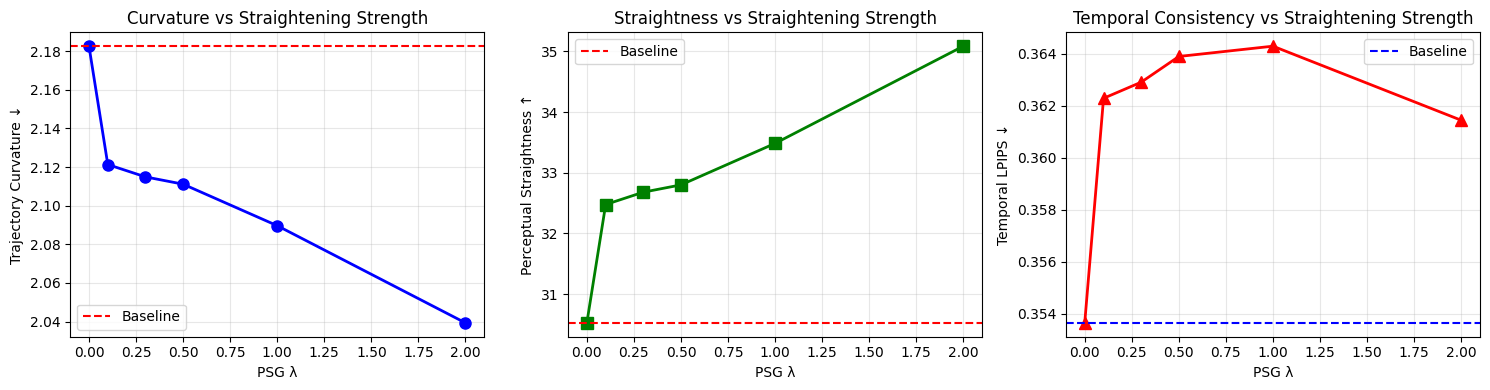

Saved lambda sweep plot.


In [ ]:
if CONFIG["run_degree_ablation"]:
    degree_results = {}
    print("Degree-of-straightening sweep...")

    for lam in CONFIG["degree_lambdas"]:
        torch.cuda.empty_cache()
        print(f"  λ={lam:.2f}", end=" ", flush=True)

        frames = vpipe.generate(
            CONFIG["prompt"], CONFIG["n_frames"], CONFIG["base_seed"],
            use_psg    = (lam > 0),
            psg_lambda = lam,
            psg_n      = CONFIG["psg_n_refine"],
            psg_start  = CONFIG["psg_start_step"],
        )
        m = compute_metrics(frames, perc_model)
        degree_results[lam] = m

        sub = results/"degree_ablation"/f"lambda_{lam:.2f}"
        sub.mkdir(exist_ok=True)
        save_video(frames, sub/"video.mp4", CONFIG["fps"])

        print(f"→ curv={m['curvature']:.4f}  straight={m['straightness']:.1f}  "
              f"t-lpips={m['temporal_lpips']:.4f}")

    # ── Plots ──────────────────────────────────────────────────────────────────
    lambdas  = CONFIG["degree_lambdas"]
    curvs    = [degree_results[l]["curvature"]      for l in lambdas]
    straights= [degree_results[l]["straightness"]   for l in lambdas]
    tlpips   = [degree_results[l]["temporal_lpips"] for l in lambdas]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(lambdas, curvs,     "bo-", lw=2, ms=8)
    axes[0].axhline(baseline_m["curvature"],  ls="--", color="red", label="Baseline")
    axes[0].set_xlabel("PSG λ"); axes[0].set_ylabel("Trajectory Curvature ↓")
    axes[0].set_title("Curvature vs Straightening Strength"); axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(lambdas, straights, "gs-", lw=2, ms=8)
    axes[1].axhline(baseline_m["straightness"], ls="--", color="red", label="Baseline")
    axes[1].set_xlabel("PSG λ"); axes[1].set_ylabel("Perceptual Straightness ↑")
    axes[1].set_title("Straightness vs Straightening Strength"); axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(lambdas, tlpips,    "r^-", lw=2, ms=8)
    axes[2].axhline(baseline_m["temporal_lpips"], ls="--", color="blue", label="Baseline")
    axes[2].set_xlabel("PSG λ"); axes[2].set_ylabel("Temporal LPIPS ↓")
    axes[2].set_title("Temporal Consistency vs Straightening Strength"); axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results/"degree_ablation"/"lambda_sweep.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved lambda sweep plot.")
else:
    degree_results = {}


## 12 · PSG Timing Ablation

**When should PSG start?** The paper notes that applying PSG too early (when frames are still far from the natural-image manifold) acts like a temporal low-pass filter, causing blurring rather than perceptually natural smoothing.

We vary `psg_start_step` $\in \{0, 5, 8, 12, 18\}$ with 25 total DDIM steps.


PSG timing ablation...
  start_step= 0 

→ curv=2.0426  straight=35.0
  start_step= 5 

→ curv=2.1106  straight=32.8
  start_step= 8 

→ curv=2.1062  straight=33.0
  start_step=12 

→ curv=2.1498  straight=31.6
  start_step=18 

→ curv=2.1508  straight=31.5


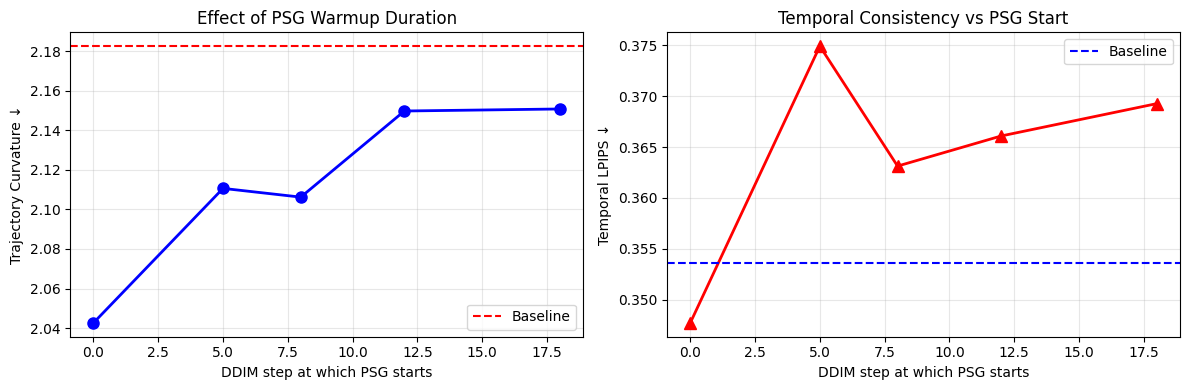

In [ ]:
if CONFIG["run_timing_ablation"]:
    timing_results = {}
    print("PSG timing ablation...")

    for start in CONFIG["timing_start_steps"]:
        torch.cuda.empty_cache()
        print(f"  start_step={start:2d}", end=" ", flush=True)

        frames = vpipe.generate(
            CONFIG["prompt"], CONFIG["n_frames"], CONFIG["base_seed"],
            use_psg=True, psg_lambda=CONFIG["psg_lambda"],
            psg_n=CONFIG["psg_n_refine"], psg_start=start,
        )
        m = compute_metrics(frames, perc_model)
        timing_results[start] = m

        sub = results/"timing_ablation"/f"start_{start}"
        sub.mkdir(exist_ok=True)
        save_video(frames, sub/"video.mp4", CONFIG["fps"])
        print(f"→ curv={m['curvature']:.4f}  straight={m['straightness']:.1f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    steps  = CONFIG["timing_start_steps"]
    curvs  = [timing_results[s]["curvature"]    for s in steps]
    tlpips = [timing_results[s]["temporal_lpips"] for s in steps]

    axes[0].plot(steps, curvs, "bo-", lw=2, ms=8)
    axes[0].axhline(baseline_m["curvature"], ls="--", color="red", label="Baseline")
    axes[0].set_xlabel("DDIM step at which PSG starts")
    axes[0].set_ylabel("Trajectory Curvature ↓")
    axes[0].set_title("Effect of PSG Warmup Duration")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(steps, tlpips, "r^-", lw=2, ms=8)
    axes[1].axhline(baseline_m["temporal_lpips"], ls="--", color="blue", label="Baseline")
    axes[1].set_xlabel("DDIM step at which PSG starts")
    axes[1].set_ylabel("Temporal LPIPS ↓")
    axes[1].set_title("Temporal Consistency vs PSG Start")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results/"timing_ablation"/"timing_sweep.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    timing_results = {}


## 13 · Feature-Space Ablation (Novel Extension)

**Question:** Does it matter *where* we measure curvature?

The paper advocates V1 space (RetinalDN → GaborV1). But what if we applied the curvature penalty in:
- **Pixel space** — raw RGB values, no perceptual processing
- **Retina space** — after RetinalDN only (DoG + gain control)
- **V1 space** — full perceptual model (paper's approach)

This ablation directly validates the design choice in the PSH pipeline.
**Hypothesis:** V1 space provides the most meaningful gradient signal because it captures perceptually relevant structure rather than spurious pixel correlations.


Feature-space ablation (pixel / retina / V1)...
  feature_fn=pixel 

→ curv=2.1328  straight=32.1
  feature_fn=retina 

→ curv=2.1261  straight=32.3
  feature_fn=v1 

→ curv=2.1093  straight=32.9


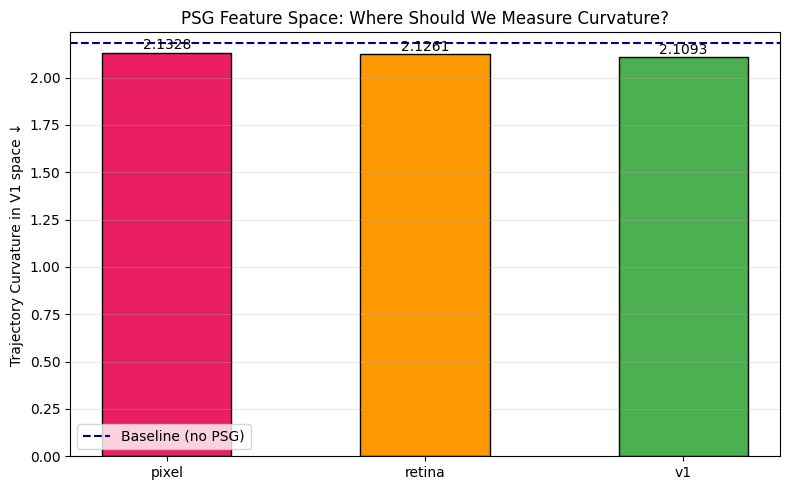

In [ ]:
if CONFIG["run_feature_ablation"]:
    feat_results = {}
    print("Feature-space ablation (pixel / retina / V1)...")

    for fn in ["pixel", "retina", "v1"]:
        torch.cuda.empty_cache()
        print(f"  feature_fn={fn}", end=" ", flush=True)

        frames = vpipe.generate(
            CONFIG["prompt"], CONFIG["n_frames"], CONFIG["base_seed"],
            use_psg=True, psg_lambda=CONFIG["psg_lambda"],
            psg_n=CONFIG["psg_n_refine"], psg_start=CONFIG["psg_start_step"],
            feature_fn=fn,
        )
        m = compute_metrics(frames, perc_model)   # always evaluate in V1 space
        feat_results[fn] = m

        sub = results/"feature_ablation"/fn
        sub.mkdir(exist_ok=True)
        save_video(frames, sub/"video.mp4", CONFIG["fps"])
        print(f"→ curv={m['curvature']:.4f}  straight={m['straightness']:.1f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    labels = list(feat_results.keys())
    curvs  = [feat_results[k]["curvature"] for k in labels]
    bars   = ax.bar(labels, curvs, color=["#E91E63","#FF9800","#4CAF50"],
                    edgecolor="black", width=0.5)
    ax.axhline(baseline_m["curvature"], ls="--", color="navy", label="Baseline (no PSG)")
    for b, v in zip(bars, curvs):
        ax.text(b.get_x()+b.get_width()/2, v+0.001, f"{v:.4f}", ha="center", va="bottom")
    ax.set_ylabel("Trajectory Curvature in V1 space ↓")
    ax.set_title("PSG Feature Space: Where Should We Measure Curvature?")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(results/"feature_ablation"/"feature_space.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    feat_results = {}


## 14 · Combined PSG + MPES

Run MPES with K=2 paths, each using PSG internally.  
This should provide the best perception–distortion trade-off by simultaneously reducing curvature (PSG) and stochastic variance (MPES).


In [ ]:
if CONFIG["run_combined"]:
    torch.cuda.empty_cache()
    t0 = time.time()
    print("PSG + MPES combined...")

    combined_frames = vpipe.generate_mpes(
        CONFIG["prompt"], CONFIG["n_frames"],
        k=CONFIG["mpes_k"], fusion="pixel",
        use_psg    = True,
        psg_lambda = CONFIG["psg_lambda"],
        psg_n      = CONFIG["psg_n_refine"],
        psg_start  = CONFIG["psg_start_step"],
    )
    combined_m = compute_metrics(combined_frames, perc_model)
    save_video(combined_frames,  results/"combined"/"video.mp4", CONFIG["fps"])
    save_frames(combined_frames, results/"combined"/"frames")

    print(f"Done in {time.time()-t0:.1f}s")
    print_metrics("Combined PSG+MPES", combined_m)
else:
    combined_m = None


PSG + MPES combined...
  Path 1/2 (seed=42)


  Path 2/2 (seed=7961)


Done in 38.1s
  Combined PSG+MPES       curv=2.0839  straight=33.7  t-lpips=0.4349  t-mse=0.12081


## 15 · Results & Visualisation

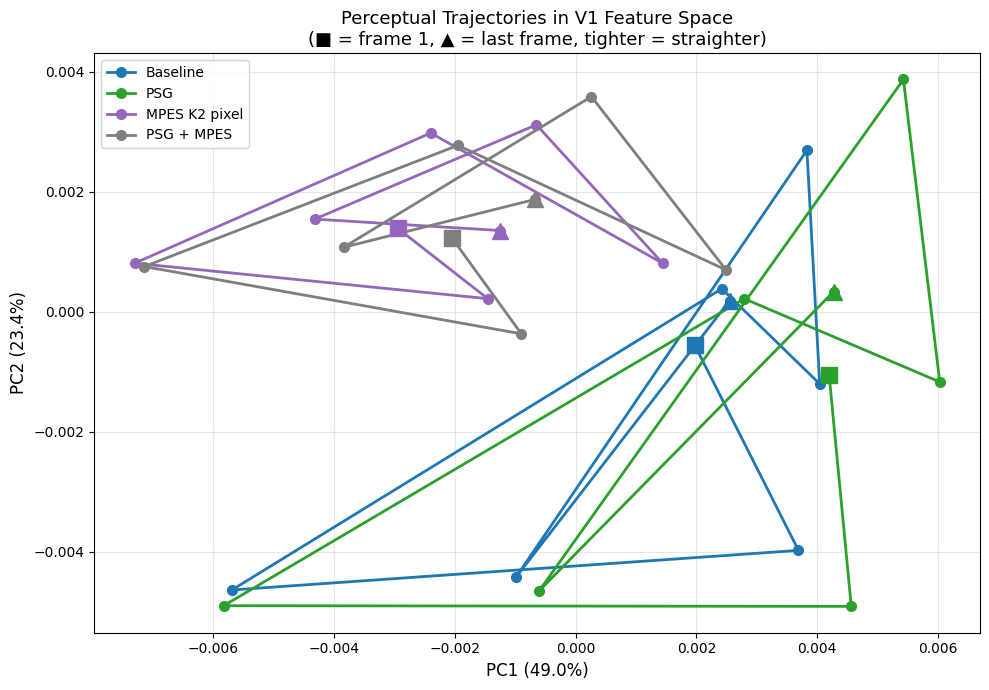

In [ ]:
# ── 15a: Perceptual trajectory visualisation (PCA) ────────────────────────────

def plot_trajectories(feat_dict: dict, out_path):
    """Project [N, D] feature arrays to 2D via PCA and plot trajectories."""
    all_f = np.vstack(list(feat_dict.values()))
    pca   = PCA(n_components=2).fit(all_f)

    colors = plt.cm.tab10(np.linspace(0, 0.7, len(feat_dict)))
    fig, ax = plt.subplots(figsize=(10, 7))

    for (label, feats), col in zip(feat_dict.items(), colors):
        proj = pca.transform(feats)
        ax.plot(proj[:,0], proj[:,1], "-o", lw=2, color=col, label=label, ms=7)
        ax.plot(proj[ 0,0], proj[ 0,1], "s",  color=col, ms=12, zorder=5)   # start
        ax.plot(proj[-1,0], proj[-1,1], "^",  color=col, ms=12, zorder=5)   # end

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
    ax.set_title("Perceptual Trajectories in V1 Feature Space\n"
                 "(■ = frame 1, ▲ = last frame, tighter = straighter)", fontsize=13)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

# Collect features for trajectory plot
traj_dict = {"Baseline": baseline_m["features"]}
if psg_m:            traj_dict["PSG"]          = psg_m["features"]
if mpes_results.get("K2_pixel"): traj_dict["MPES K2 pixel"] = mpes_results["K2_pixel"]["features"]
if combined_m:       traj_dict["PSG + MPES"]   = combined_m["features"]

plot_trajectories(traj_dict, results/"trajectories"/"perceptual_trajectories.png")


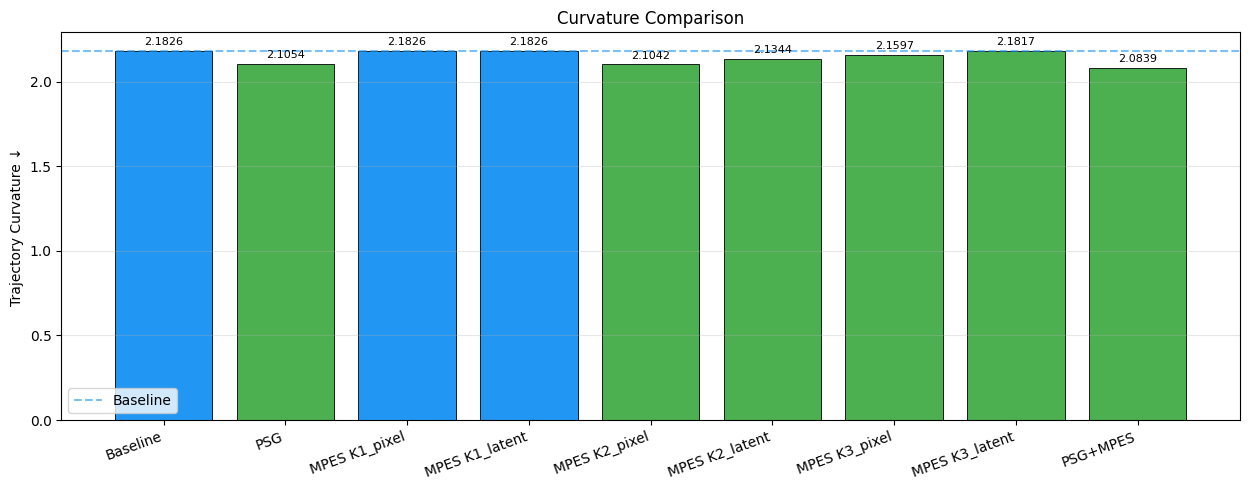

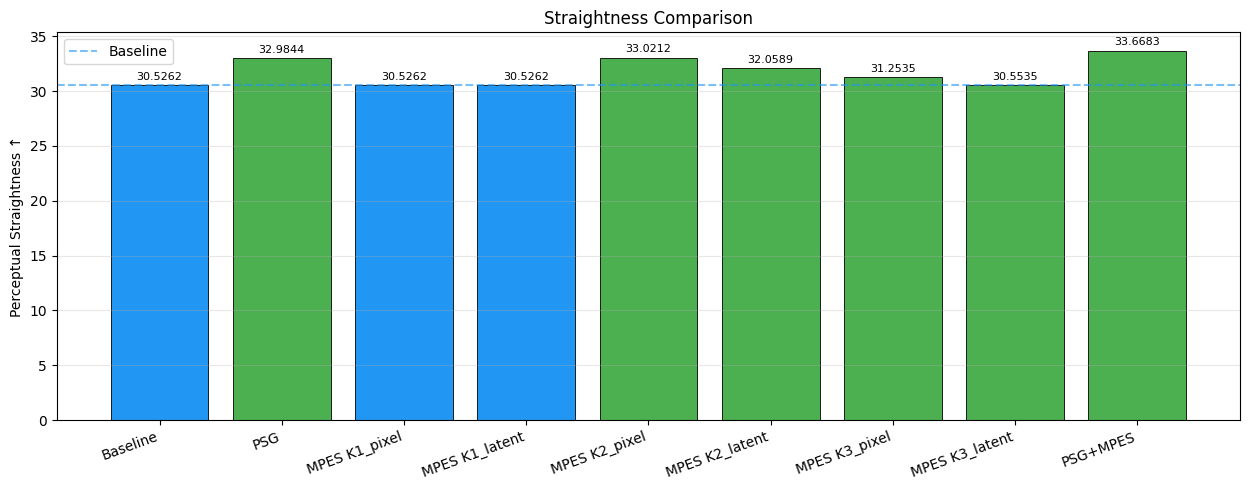

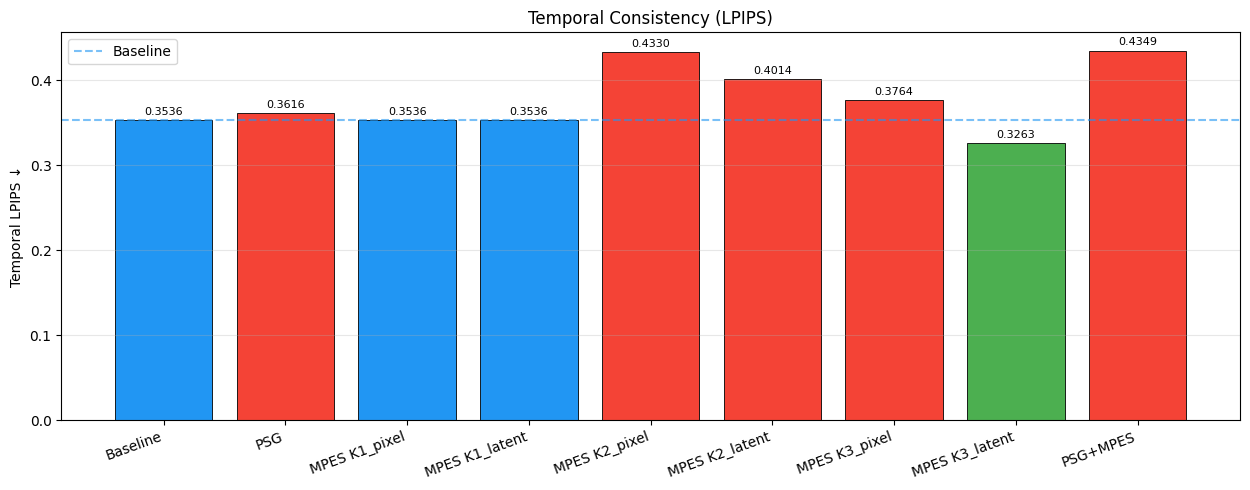

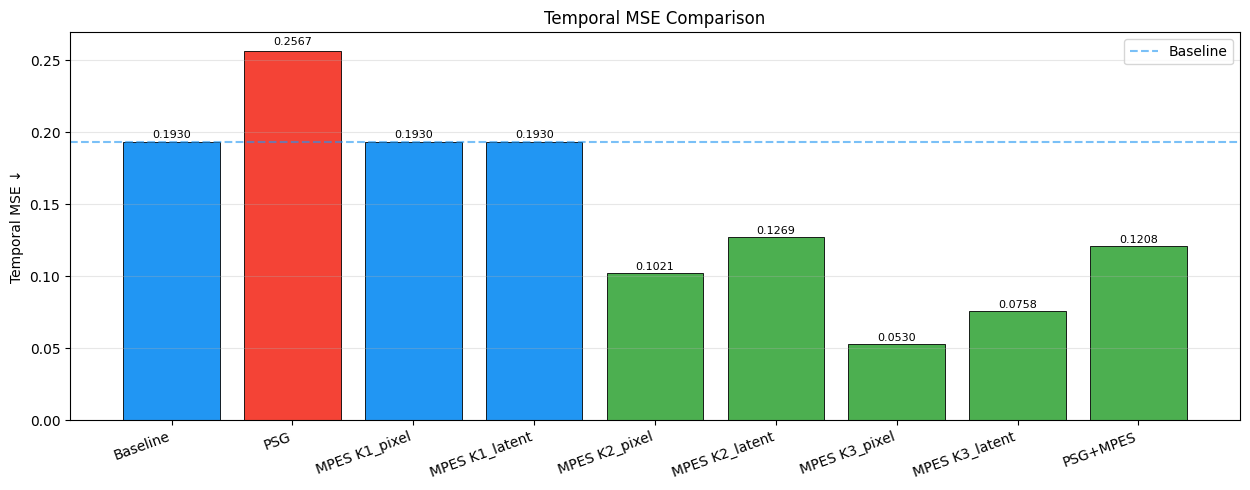

In [ ]:
# ── 15b: Summary bar charts ────────────────────────────────────────────────────

def bar_chart(all_results: dict, metric: str, ylabel: str, title: str, out: Path,
              higher_better: bool = False):
    labels = list(all_results.keys())
    vals   = [all_results[k][metric] for k in labels]
    base   = vals[0]

    def _color(v):
        if v == base: return "#2196F3"
        better = v < base if not higher_better else v > base
        return "#4CAF50" if better else "#F44336"

    fig, ax = plt.subplots(figsize=(max(8, len(labels)*1.4), 5))
    bars = ax.bar(labels, vals, color=[_color(v) for v in vals],
                  edgecolor="black", linewidth=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v*1.01, f"{v:.4f}",
                ha="center", va="bottom", fontsize=8)
    ax.axhline(base, ls="--", color="#2196F3", alpha=0.6, label="Baseline")
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()

# Assemble all top-level results
all_res = {"Baseline": baseline_m}
if psg_m:       all_res["PSG"]         = psg_m
for k,v in mpes_results.items():
    all_res[f"MPES {k}"] = v
if combined_m:  all_res["PSG+MPES"]    = combined_m

bar_chart(all_res, "curvature",      "Trajectory Curvature ↓", "Curvature Comparison",
          results/"plots"/"curvature.png")
bar_chart(all_res, "straightness",   "Perceptual Straightness ↑", "Straightness Comparison",
          results/"plots"/"straightness.png", higher_better=True)
bar_chart(all_res, "temporal_lpips", "Temporal LPIPS ↓", "Temporal Consistency (LPIPS)",
          results/"plots"/"temporal_lpips.png")
bar_chart(all_res, "temporal_mse",   "Temporal MSE ↓",   "Temporal MSE Comparison",
          results/"plots"/"temporal_mse.png")


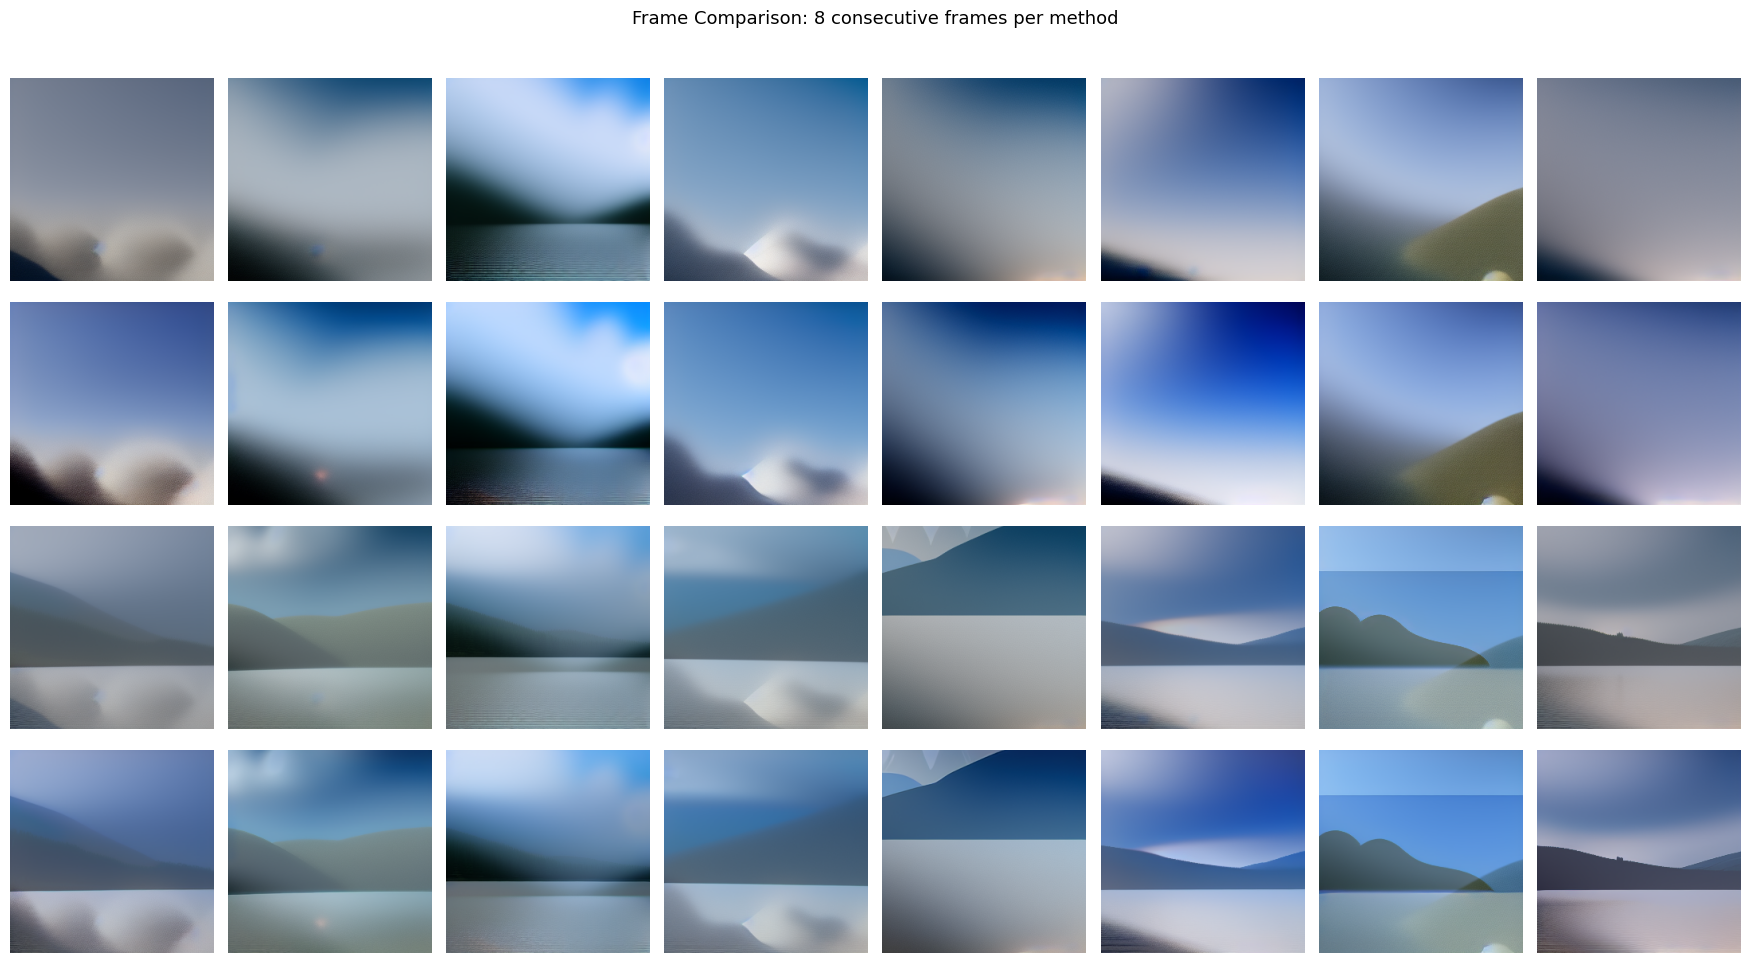

In [ ]:
# ── 15c: Frame comparison grid ─────────────────────────────────────────────────

def frame_grid(frames_dict: dict, out: Path, n_show: int = 8):
    """Show all frames for each method in a grid."""
    methods = list(frames_dict.keys())
    n_rows  = len(methods)
    fig, axes = plt.subplots(n_rows, n_show, figsize=(n_show*2.2, n_rows*2.4))
    if n_rows == 1: axes = axes[None]

    for r, (name, frames) in enumerate(frames_dict.items()):
        pils = to_pil(frames[:n_show])
        for c, img in enumerate(pils):
            axes[r, c].imshow(img)
            axes[r, c].axis("off")
            if c == 0:
                axes[r, c].set_ylabel(name, fontsize=10, rotation=0,
                                       labelpad=80, va="center", ha="right")

    plt.suptitle("Frame Comparison: 8 consecutive frames per method", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()

grid_dict = {"Baseline": baseline_frames.cpu()}
if psg_m is not None:
    grid_dict["PSG"] = psg_frames.cpu()
if mpes_frames.get("K2_pixel") is not None:
    grid_dict["MPES K2 pixel"] = mpes_frames["K2_pixel"]
if combined_m is not None:
    grid_dict["PSG+MPES"] = combined_frames.cpu()

frame_grid(grid_dict, results/"plots"/"frame_grid.png")


In [ ]:
# ── 15d: Save numeric summary ──────────────────────────────────────────────────

summary = {
    "config" : {k: str(v) for k, v in CONFIG.items() if k != "dtype"},
    "results": {
        name: {kk: vv for kk, vv in m.items() if kk != "features"}
        for name, m in all_res.items()
    },
    "degree_ablation": {
        str(lam): {kk: vv for kk, vv in m.items() if kk != "features"}
        for lam, m in degree_results.items()
    } if degree_results else {},
    "timing_ablation": {
        str(s): {kk: vv for kk, vv in m.items() if kk != "features"}
        for s, m in timing_results.items()
    } if timing_results else {},
    "feature_ablation": {
        fn: {kk: vv for kk, vv in m.items() if kk != "features"}
        for fn, m in feat_results.items()
    } if feat_results else {},
}

with open(results/"plots"/"summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n=== FINAL SUMMARY ===")
print(f"{'Method':<22}  {'Curvature↓':>10}  {'Straight↑':>10}  {'t-LPIPS↓':>9}")
print("-" * 60)
for name, m in all_res.items():
    print(f"{name:<22}  {m['curvature']:>10.4f}  "
          f"{m['straightness']:>10.2f}  {m['temporal_lpips']:>9.4f}")
print("\nAll results saved to:", results.resolve())



=== FINAL SUMMARY ===
Method                  Curvature↓   Straight↑   t-LPIPS↓
------------------------------------------------------------
Baseline                    2.1826       30.53     0.3536
PSG                         2.1054       32.98     0.3616
MPES K1_pixel               2.1826       30.53     0.3536
MPES K1_latent              2.1826       30.53     0.3536
MPES K2_pixel               2.1042       33.02     0.4330
MPES K2_latent              2.1344       32.06     0.4014
MPES K3_pixel               2.1597       31.25     0.3764
MPES K3_latent              2.1817       30.55     0.3263
PSG+MPES                    2.0839       33.67     0.4349

All results saved to: C:\Users\Suchit\Old Storage\iith\2025-26\sem6\CV project\Perceptual_Straightening_in_Video_Diffusion\experiment-results


## 16 · Discussion & Future Directions

### What to expect from results:
1. **PSG** should reduce curvature and increase straightness, particularly evident in the trajectory plots. The effect on temporal LPIPS is secondary — PSG primarily fixes *naturalness of motion*, not pixel-level consistency.
2. **MPES** should reduce temporal MSE and LPIPS by averaging out stochastic pixel noise. Pixel-space fusion should beat latent-space fusion (per the paper).
3. **Degree ablation** should reveal a sweet spot around λ=0.3–0.5: stronger guidance reduces curvature but eventually harms temporal coherence (over-smoothing).
4. **Timing ablation** should show that early PSG (step 0) is harmful (blurring), while late PSG (step 18+) has less impact. Optimal is mid-range (~steps 8–12).
5. **Feature space ablation** should confirm V1 > Retina > Pixel for meaningful gradient signal.

### Proposed extensions beyond the paper:
| Idea | Motivation |
|------|-----------|
| **Adaptive λ scheduler** — increase λ_PS as t→0 | Early denoising needs freedom; late steps benefit most from curvature penalty |
| **Margin-based curvature penalty** (Huber loss) | Penalise only curvature above a natural threshold, not all curvature |
| **Cross-frame attention injection** | PSG at pixel level can be combined with latent-level cross-frame attention sharing |
| **K-path warm ensemble** — merge K paths at step 15, continue as 1 | Captures early diversity, saves compute vs full K-path inference |
| **Quality-weighted MPES** — weight paths by frame sharpness | Better paths get higher weight; inspired by Korkmaz et al. [38] |
| **Perceptual-space MPES** — average in V1 feature space | Instead of averaging pixels, average trajectories in perceptual space |
